<a href="https://colab.research.google.com/github/MoAftaab/ClipMamba-Adaptive-State-Space-Regulation-for-Adversarial-Defense-in-Visual-Mamba-Architectures/blob/main/AFTAAB_CAPSTONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Demo
Run FGSM and PGD attacks interactively on CIFAR-10 samples.


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
Tesla T4


In [ ]:
# If running in a fresh Colab, first install/upgrade torch & torchvision (optional but recommended)
# !pip install -q torch torchvision

import torch
import torchvision
import torchvision.transforms as transforms

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Standard CIFAR-10 normalization values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),   # mean
                         (0.2023, 0.1994, 0.2010))   # std
])

# Root directory inside Colab; it will be created automatically
data_root = "./data"

# Train dataset and loader
trainset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Test dataset and loader
testset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Class names
classes = trainset.classes
print("Classes:", classes)

# Quick sanity check: get one batch
images, labels = next(iter(trainloader))
print("Batch shape:", images.shape, "Labels shape:", labels.shape)


Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 44.2MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch shape: torch.Size([128, 3, 32, 32]) Labels shape: torch.Size([128])


In [ ]:
# ============================================================
# Colab-ready CNN for CIFAR-10 (PyTorch)
# ============================================================
!pip install -q torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 1. Data (same normalization as before)
# -----------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

data_root = "./data"

trainset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

testset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

classes = trainset.classes
print("Classes:", classes)

# -----------------------------
# 2. CNN Model definition
#    Simple but decent baseline for CIFAR-10
# -----------------------------
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        # Input: 3 x 32 x 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)     # 32 x 32 x 32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)    # 64 x 32 x 32
        self.pool = nn.MaxPool2d(2, 2)                              # 64 x 16 x 16
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)   # 128 x 16 x 16
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # 128 x 16 x 16
        # After second pool: 128 x 8 x 8
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.pool(x)  # 128 x 8 x 8

        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = CIFAR10_CNN().to(device)
print(model)

# -----------------------------
# 3. Loss & Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

# -----------------------------
# 4. Training loop
# -----------------------------
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch}], Step [{i+1}/{len(trainloader)}], "
                  f"Loss: {running_loss / total:.4f}, "
                  f"Acc: {100.0 * correct / total:.2f}%")

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    print(f"Epoch {epoch} Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%")

# -----------------------------
# 5. Test function
# -----------------------------
def test():
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss /= total
    acc = 100.0 * correct / total
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {acc:.2f}%")
    return acc

# -----------------------------
# 6. Run training
# -----------------------------
num_epochs = 10  # increase to 30+ for better accuracy
for epoch in range(1, num_epochs + 1):
    train_one_epoch(epoch)
    test_acc = test()

# After training, you can save the model for later FGSM/PGD attacks
torch.save(model.state_dict(), "cifar10_cnn.pth")
print("Model saved to cifar10_cnn.pth")


Using device: cuda
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR10_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 1. Recreate model and load weights (if in a new Colab session)
# -----------------------------
import torch.nn as nn
import torch.nn.functional as F

class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = CIFAR10_CNN().to(device)

# If you just finished training in the same session, you can skip this load
model.load_state_dict(torch.load("cifar10_cnn.pth", map_location=device))
print("Weights loaded from cifar10_cnn.pth")

# -----------------------------
# 2. Clean accuracy on CIFAR-10 test set
# -----------------------------
def evaluate_clean_accuracy(model, testloader, device):
    model.eval()  # important: disable dropout, use running stats for BatchNorm
    correct = 0
    total = 0

    with torch.no_grad():  # disable gradient computation for speed and memory
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = outputs.max(1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    acc = 100.0 * correct / total
    print(f"Clean test accuracy: {acc:.2f}% on {total} samples")
    return acc

clean_acc = evaluate_clean_accuracy(model, testloader, device)


Using device: cuda
Weights loaded from cifar10_cnn.pth
Clean test accuracy: 75.96% on 10000 samples


In [ ]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------------------
# 1. FGSM attack function (L-infinity bounded)
# -------------------------------------------------
def fgsm_attack(images, epsilon, data_grad):
    # Element-wise sign of the gradient
    sign_data_grad = data_grad.sign()
    # Create perturbed image
    perturbed_images = images + epsilon * sign_data_grad
    # Clamp to valid range of normalized CIFAR-10 tensor
    # CIFAR-10 is normalized, but clipping to [-1, 1] is often reasonable
    perturbed_images = torch.clamp(perturbed_images, -3.0, 3.0)
    return perturbed_images

# -------------------------------------------------
# 2. Evaluate model under FGSM on the whole test set
#    Assumes: model, testloader, criterion already defined
# -------------------------------------------------
def eval_fgsm(model, testloader, device, epsilon):
    model.eval()
    adv_correct = 0
    adv_total = 0
    adv_examples = []  # will store a few (orig, adv, label, adv_pred)

    for batch_idx, (images, labels) in enumerate(testloader):
        images, labels = images.to(device), labels.to(device)

        # Enable gradient on inputs
        images.requires_grad = True

        # Forward pass
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)

        # Zero all existing gradients
        model.zero_grad()
        loss.backward()

        # Collect gradients on the inputs
        data_grad = images.grad.data

        # Generate adversarial examples
        perturbed_images = fgsm_attack(images, epsilon, data_grad)

        # Re-classify the perturbed images
        outputs_adv = model(perturbed_images)
        _, preds_adv = outputs_adv.max(1)

        adv_total += labels.size(0)
        adv_correct += preds_adv.eq(labels).sum().item()

        # Save some examples for visualization (first few batches)
        if len(adv_examples) < 10:
            # Move to CPU and detach
            imgs_cpu = images.detach().cpu()
            adv_cpu = perturbed_images.detach().cpu()
            lbls_cpu = labels.detach().cpu()
            preds_cpu = preds_adv.detach().cpu()
            for i in range(min(5, imgs_cpu.size(0))):
                adv_examples.append((
                    imgs_cpu[i],          # original normalized image
                    adv_cpu[i],           # adversarial normalized image
                    int(lbls_cpu[i]),     # true label
                    int(preds_cpu[i])     # adversarial prediction
                ))

    adv_acc = 100.0 * adv_correct / adv_total
    print(f"FGSM epsilon={epsilon:.4f} -> Adversarial test accuracy: {adv_acc:.2f}%")
    return adv_acc, adv_examples

# -------------------------------------------------
# 3. Run FGSM for a chosen epsilon
# -------------------------------------------------
epsilon = 8.0 / 255.0   # common CIFAR-10 setting
fgsm_acc, fgsm_examples = eval_fgsm(model, testloader, device, epsilon)


Using device: cuda
FGSM epsilon=0.0314 -> Adversarial test accuracy: 30.11%


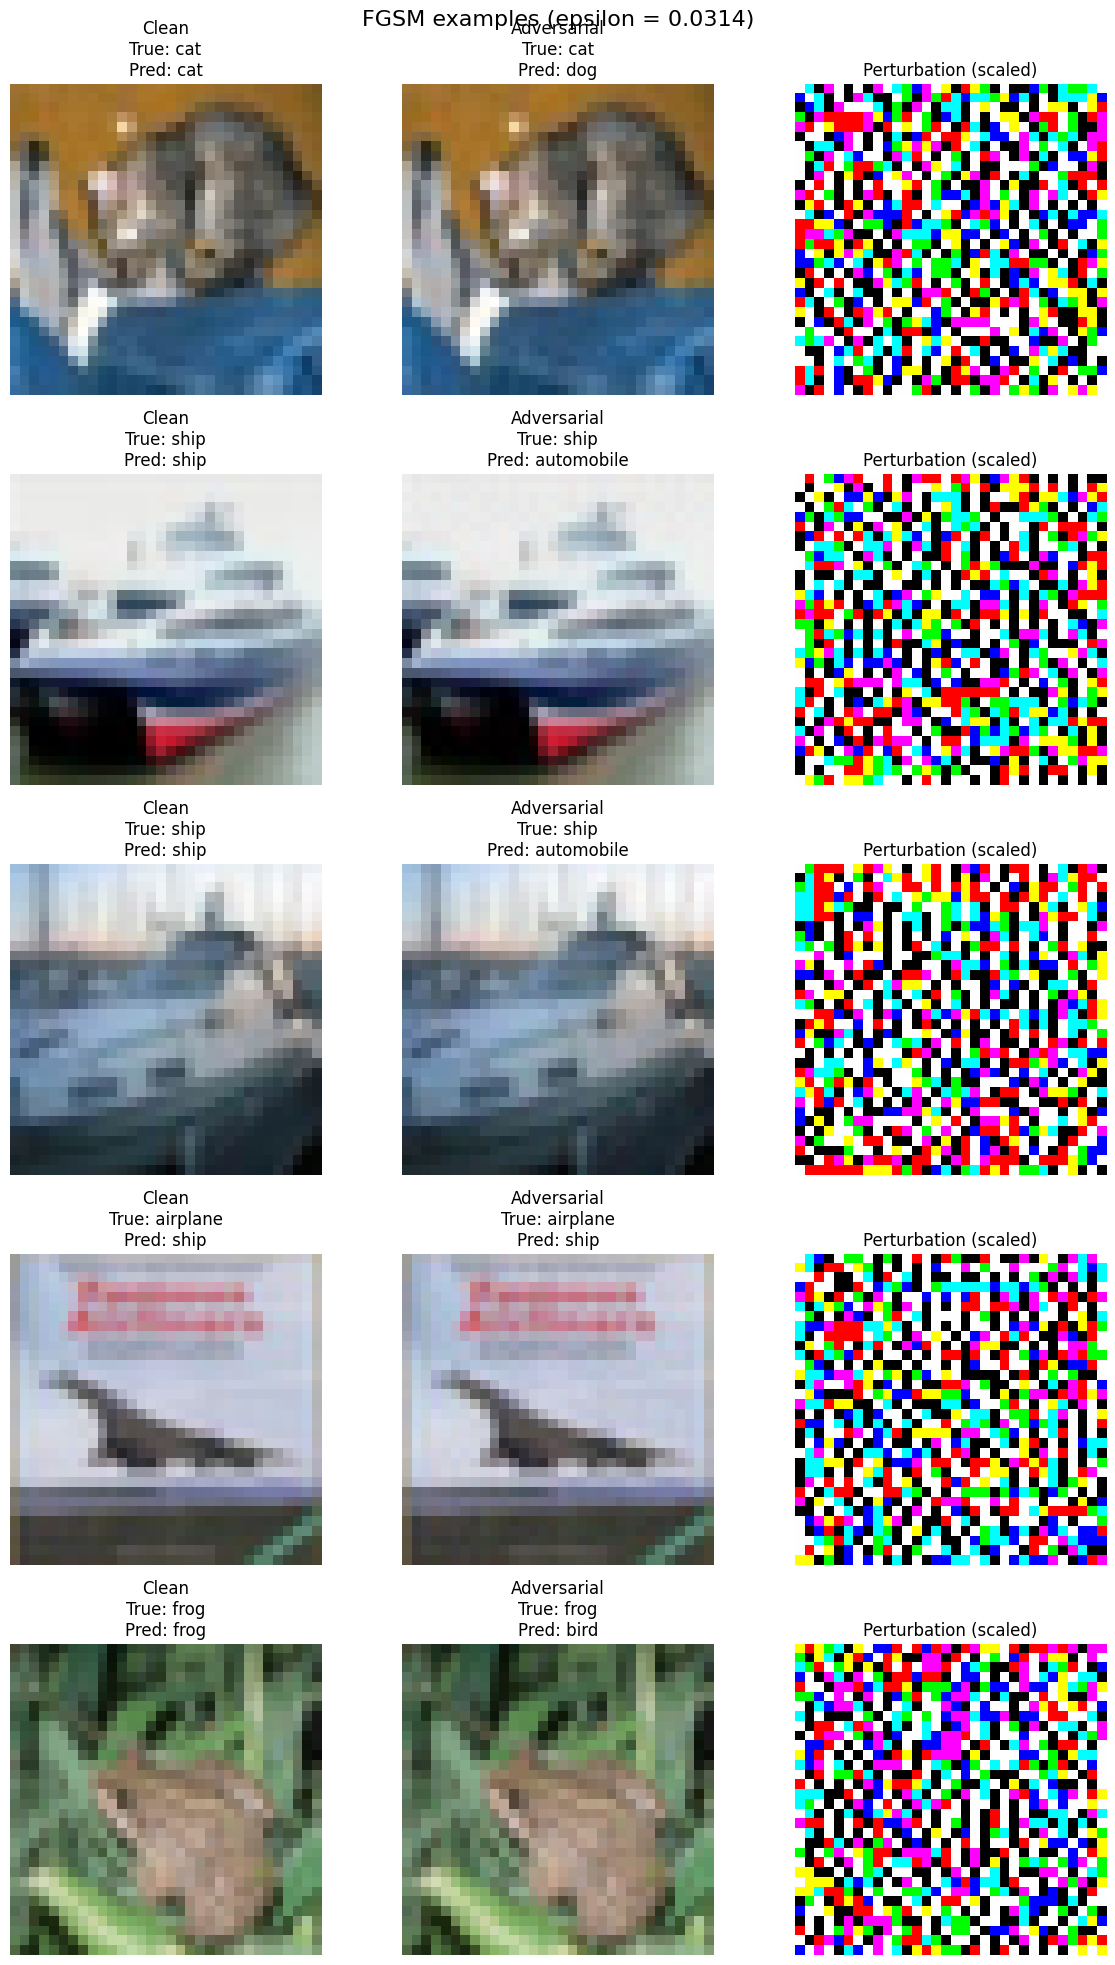

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 normalization stats used earlier
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR_STD  = np.array([0.2023, 0.1994, 0.2010])

classes = trainset.classes  # from your previous code

# -------------------------------------------------
# 1. Helper: unnormalize tensor and convert to HWC numpy
# -------------------------------------------------
def unnormalize_and_to_numpy(img_tensor):
    """
    img_tensor: (3, H, W) normalized with CIFAR_MEAN, CIFAR_STD
    returns: (H, W, 3) in [0,1] for matplotlib
    """
    img = img_tensor.detach().cpu().numpy()
    # C x H x W -> H x W x C
    img = np.transpose(img, (1, 2, 0))
    img = img * CIFAR_STD + CIFAR_MEAN
    img = np.clip(img, 0, 1)
    return img

# -------------------------------------------------
# 2. Get a single batch, run FGSM on it, and visualize
# -------------------------------------------------
def visualize_fgsm_examples(model, testloader, device, epsilon, num_images=5):
    model.eval()
    data_iter = iter(testloader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)
    images.requires_grad = True

    # Forward on clean
    outputs = model(images)
    _, preds_clean = outputs.max(1)

    # Compute loss and gradient wrt inputs
    loss = torch.nn.functional.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()

    data_grad = images.grad.data
    # Generate FGSM adversarial images
    perturbed_images = images + epsilon * data_grad.sign()
    perturbed_images = torch.clamp(perturbed_images, -3.0, 3.0)

    # Forward on adversarial
    outputs_adv = model(perturbed_images)
    _, preds_adv = outputs_adv.max(1)

    # Move to CPU for plotting
    images_cpu = images.detach().cpu()
    pert_cpu = perturbed_images.detach().cpu()
    labels_cpu = labels.detach().cpu()
    preds_clean_cpu = preds_clean.detach().cpu()
    preds_adv_cpu = preds_adv.detach().cpu()

    n = min(num_images, images_cpu.size(0))
    plt.figure(figsize=(12, 4*n))

    for i in range(n):
        orig = images_cpu[i]
        adv = pert_cpu[i]
        diff = adv - orig

        # Unnormalize for display
        orig_np = unnormalize_and_to_numpy(orig)
        adv_np = unnormalize_and_to_numpy(adv)
        # For perturbation, amplify and shift to [0,1] for visualization
        diff_np = diff.detach().cpu().numpy()
        diff_np = np.transpose(diff_np, (1, 2, 0))
        diff_np = diff_np / (2 * epsilon) + 0.5
        diff_np = np.clip(diff_np, 0, 1)

        true_cls = classes[labels_cpu[i]]
        clean_cls = classes[preds_clean_cpu[i]]
        adv_cls = classes[preds_adv_cpu[i]]

        # Original
        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(orig_np)
        plt.title(f"Clean\nTrue: {true_cls}\nPred: {clean_cls}")
        plt.axis("off")

        # Adversarial
        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(adv_np)
        plt.title(f"Adversarial\nTrue: {true_cls}\nPred: {adv_cls}")
        plt.axis("off")

        # Perturbation
        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(diff_np)
        plt.title("Perturbation (scaled)")
        plt.axis("off")

    plt.suptitle(f"FGSM examples (epsilon = {epsilon:.4f})", fontsize=16)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------
# 3. Call visualization with your trained model
# -------------------------------------------------
epsilon = 8.0 / 255.0  # 0.0314
visualize_fgsm_examples(model, testloader, device, epsilon, num_images=5)


In [ ]:
# Colab-ready PGD Attack (multi-step FGSM) for CIFAR-10
# Stronger than single-step FGSM

import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================================
# PGD Attack function (L-infinity bounded)
# ========================================
def pgd_attack(model, images, labels, epsilon, alpha, num_iter, random_start=True):
    """
    PGD: Projected Gradient Descent (multi-step FGSM)
    epsilon: max perturbation (e.g., 8/255)
    alpha: step size (e.g., 2/255)
    num_iter: attack steps (e.g., 20)
    """
    model.eval()
    original_images = images.clone().detach()

    # Setup perturbation
    if random_start:
        # Random start within epsilon ball
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        delta = torch.clamp(original_images + delta, 0, 1) - original_images
    else:
        delta = torch.zeros_like(images)

    for i in range(num_iter):
        delta.requires_grad = True
        output = model(original_images + delta)
        loss = F.cross_entropy(output, labels)

        # Compute gradient
        model.zero_grad()
        loss.backward()
        grad = delta.grad.detach()

        # Update perturbation
        delta = delta + alpha * grad.sign()
        # Project to [-eps, eps] ball
        delta = torch.clamp(delta, -epsilon, epsilon)
        # Project to valid range
        delta_data = torch.clamp(original_images + delta, 0, 1) - original_images
        delta = delta_data.detach()

    adv_images = original_images + delta
    return adv_images

# ========================================
# Evaluate PGD on full test set
# ========================================
def eval_pgd(model, testloader, device, epsilon=8/255, alpha=2/255, num_iter=20):
    model.eval()
    correct = 0
    total = 0

    print(f"PGD Attack: eps={epsilon:.4f}, alpha={alpha:.4f}, steps={num_iter}")

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        # Generate adversarial examples
        adv_images = pgd_attack(model, images, labels,
                               epsilon, alpha, num_iter)

        # Evaluate adversarial accuracy
        with torch.no_grad():
            output = model(adv_images)
            _, preds = output.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    acc = 100.0 * correct / total
    print(f"PGD adversarial accuracy: {acc:.2f}%")
    return acc

# ========================================
# Run PGD attack
# ========================================
pgd_acc = eval_pgd(model, testloader, device)

# Optional: Save some PGD examples for visualization
def get_pgd_examples(model, testloader, device, epsilon=8/255, alpha=2/255, num_iter=20):
    data_iter = iter(testloader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)
    pgd_examples = pgd_attack(model, images[:5], labels[:5], epsilon, alpha, num_iter)
    return images[:5], pgd_examples, labels[:5]

orig_imgs, pgd_imgs, pgd_labels = get_pgd_examples(model, testloader, device)
print("PGD examples saved for visualization")


Using device: cuda
PGD Attack: eps=0.0314, alpha=0.0078, steps=20
PGD adversarial accuracy: 11.23%
PGD examples saved for visualization


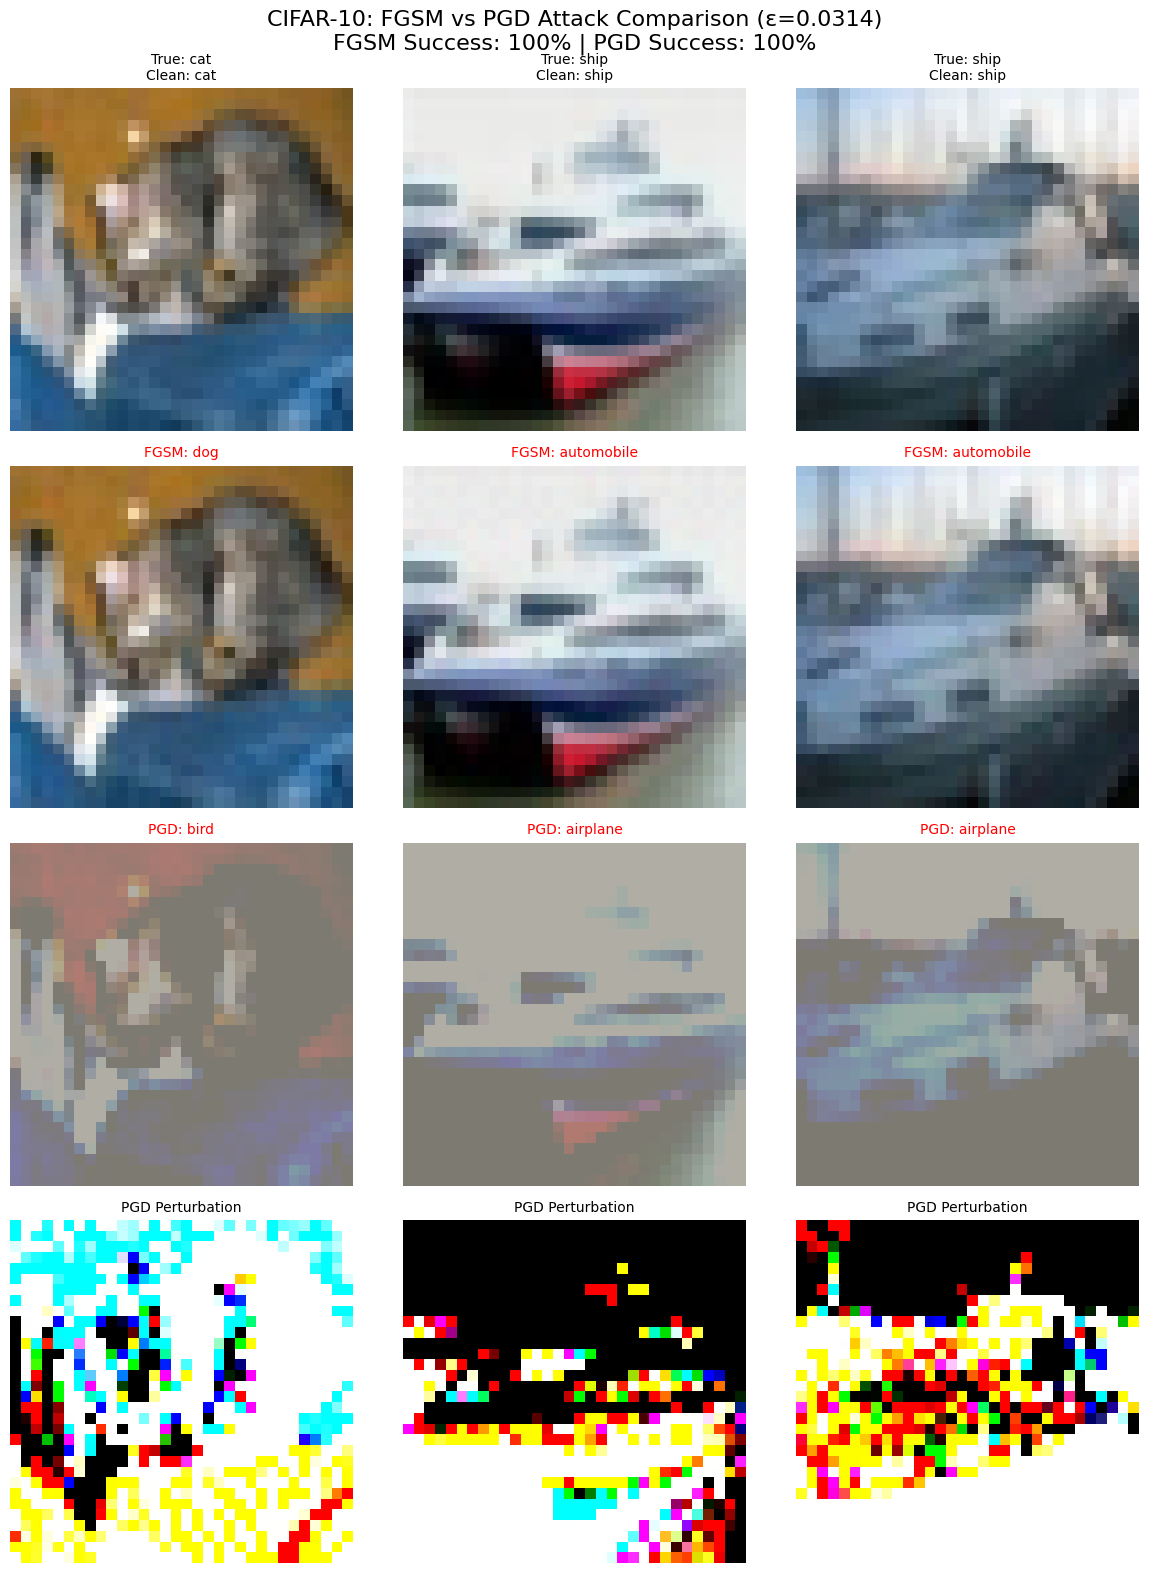

=== DETAILED RESULTS ===
Image | True | Clean | FGSM | PGD
----------------------------------------
   1 | cat    | cat    | dog    | bird  
   2 | ship   | ship   | automobile | airplane
   3 | ship   | ship   | automobile | airplane


In [ ]:
# FIXED: CIFAR-10 FGSM vs PGD Comparison - Corrected Image Shapes
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR_STD  = np.array([0.2023, 0.1994, 0.2010])
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# ========================================
# Attack Functions
# ========================================
def fgsm_batch(images, labels, epsilon):
    images.requires_grad_(True)
    output = model(images)
    loss = F.cross_entropy(output, labels)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * images.grad.data.sign()
    adv_images = images + perturbation
    return torch.clamp(adv_images, -3.0, 3.0)

def pgd_batch(images, labels, epsilon=8/255, alpha=2/255, num_iter=20):
    orig_images = images.clone().detach()
    delta = torch.zeros_like(images).uniform_(-epsilon, epsilon)
    delta = torch.clamp(orig_images + delta, 0, 1) - orig_images

    for _ in range(num_iter):
        delta.requires_grad_(True)
        output = model(orig_images + delta)
        loss = F.cross_entropy(output, labels)
        model.zero_grad()
        loss.backward()
        grad = delta.grad.detach()
        delta = delta + alpha * grad.sign()
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(orig_images + delta, 0, 1) - orig_images
        delta = delta.detach()

    return orig_images + delta

# ========================================
# Get 3 CIFAR-10 images
# ========================================
model.eval()
data_iter = iter(testloader)
images, labels = next(data_iter)
images, labels = images[:3].to(device), labels[:3].to(device)

epsilon = 8.0 / 255.0

# Attacks
fgsm_images = fgsm_batch(images.clone(), labels, epsilon)
pgd_images = pgd_batch(images.clone(), labels, epsilon)

# Predictions
with torch.no_grad():
    clean_preds = model(images).max(1)[1]
    fgsm_preds = model(fgsm_images).max(1)[1]
    pgd_preds = model(pgd_images).max(1)[1]

# ========================================
# FIXED Unnormalize + Transpose to HWC
# ========================================
def unnormalize(imgs):
    imgs_np = imgs.detach().cpu().numpy()
    # Broadcasting fix
    mean_expanded = CIFAR_MEAN.reshape(1, 3, 1, 1)
    std_expanded = CIFAR_STD.reshape(1, 3, 1, 1)
    imgs_np = imgs_np * std_expanded + mean_expanded
    imgs_np = np.clip(imgs_np, 0, 1)
    # CRITICAL: Transpose to HWC for matplotlib (B,H,W,C)
    imgs_np = np.transpose(imgs_np, (0, 2, 3, 1))
    return imgs_np

clean_np = unnormalize(images)
fgsm_np = unnormalize(fgsm_images)
pgd_np = unnormalize(pgd_images)

# Metrics
success_fgsm = (fgsm_preds != labels).float().mean().item() * 100
success_pgd = (pgd_preds != labels).float().mean().item() * 100

# ========================================
# Clean Visualization
# ========================================
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(3):
    # Clean (Row 0)
    axes[0, i].imshow(clean_np[i])
    true_cls = classes[labels[i].item()]
    clean_cls = classes[clean_preds[i].item()]
    axes[0, i].set_title(f'True: {true_cls}\nClean: {clean_cls}', fontsize=10)
    axes[0, i].axis('off')

    # FGSM (Row 1)
    axes[1, i].imshow(fgsm_np[i])
    fgsm_cls = classes[fgsm_preds[i].item()]
    color = 'red' if fgsm_preds[i] != labels[i] else 'green'
    axes[1, i].set_title(f'FGSM: {fgsm_cls}', color=color, fontsize=10)
    axes[1, i].axis('off')

    # PGD (Row 2)
    axes[2, i].imshow(pgd_np[i])
    pgd_cls = classes[pgd_preds[i].item()]
    color = 'red' if pgd_preds[i] != labels[i] else 'green'
    axes[2, i].set_title(f'PGD: {pgd_cls}', color=color, fontsize=10)
    axes[2, i].axis('off')

    # PGD Perturbation (Row 3)
    diff = pgd_images[i] - images[i]
    diff_np = diff.detach().cpu().numpy()
    diff_np = np.transpose(diff_np, (1, 2, 0))
    diff_vis = diff_np / (2 * epsilon) + 0.5
    diff_vis = np.clip(diff_vis, 0, 1)
    axes[3, i].imshow(diff_vis)
    axes[3, i].set_title('PGD Perturbation', fontsize=10)
    axes[3, i].axis('off')

plt.suptitle(f'CIFAR-10: FGSM vs PGD Attack Comparison (ε={epsilon:.4f})\n'
             f'FGSM Success: {success_fgsm:.0f}% | PGD Success: {success_pgd:.0f}%',
             fontsize=16)
plt.tight_layout()
plt.show()

# ========================================
# Results Table
# ========================================
print("=== DETAILED RESULTS ===")
print("Image | True | Clean | FGSM | PGD")
print("-" * 40)
for i in range(3):
    print(f"{i+1:4} | {classes[labels[i].item()]:6} | "
          f"{classes[clean_preds[i].item()]:6} | "
          f"{classes[fgsm_preds[i].item()]:6} | "
          f"{classes[pgd_preds[i].item()]:6}")


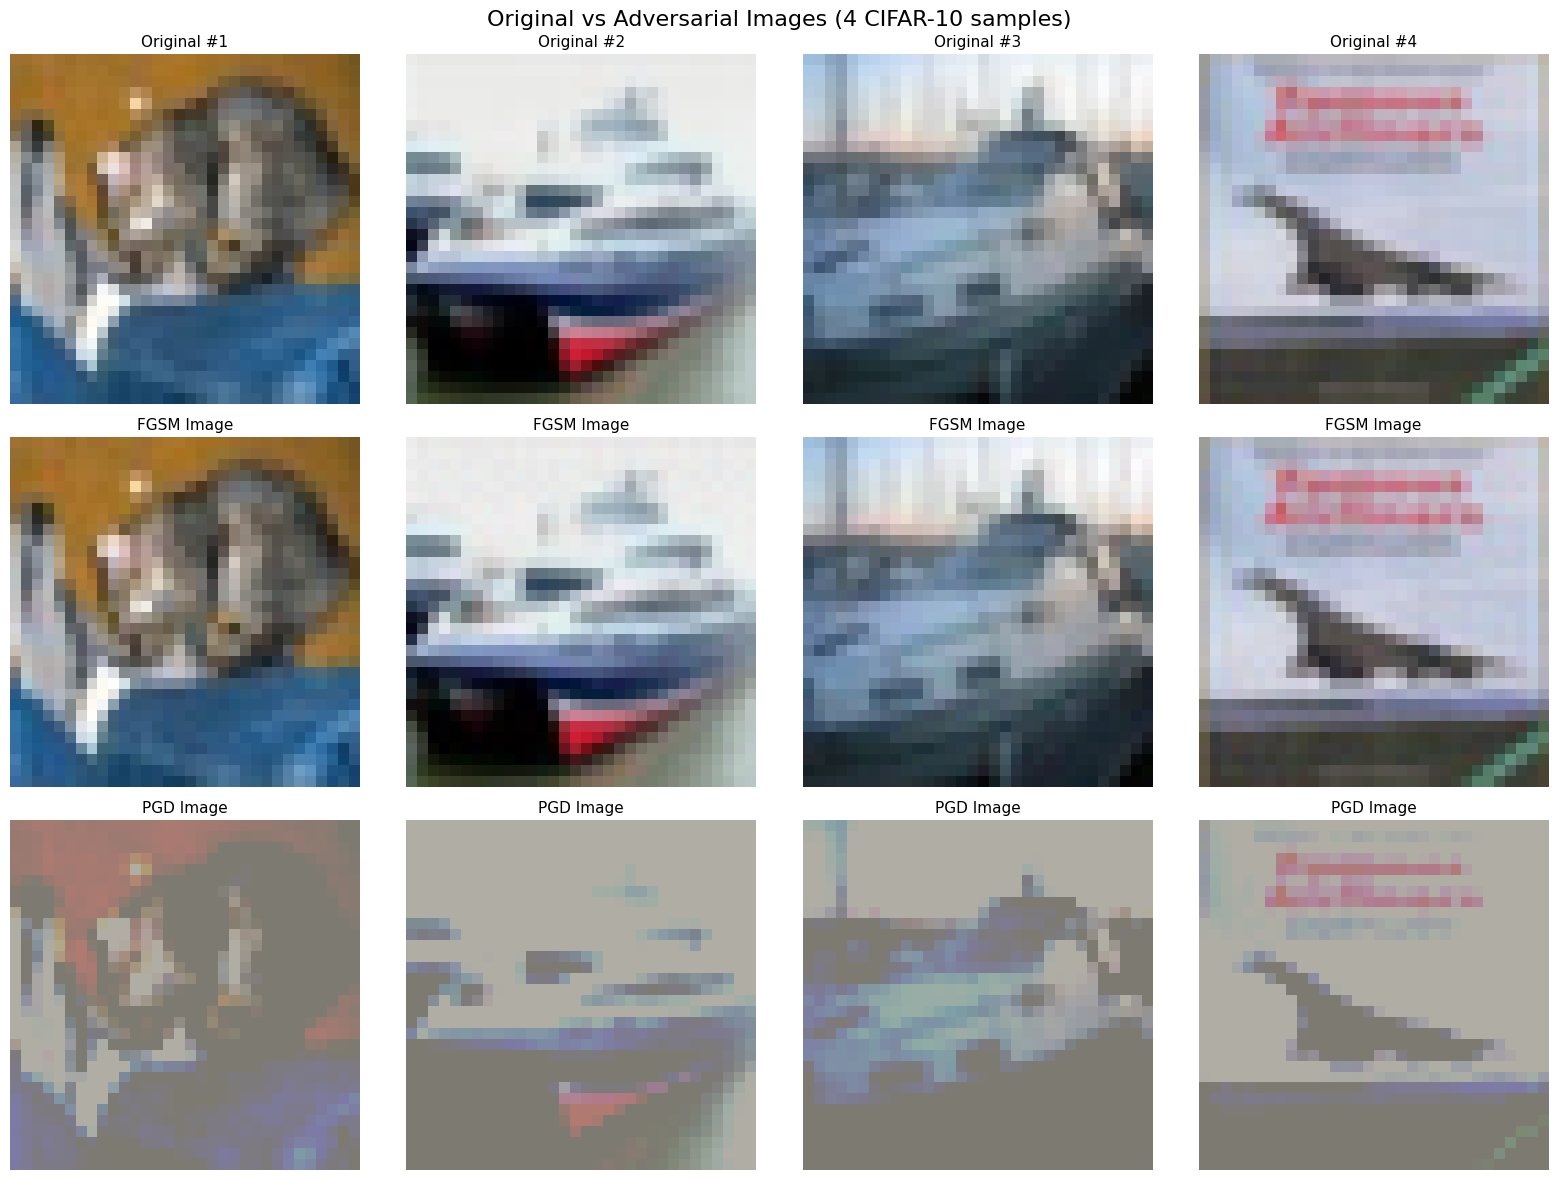

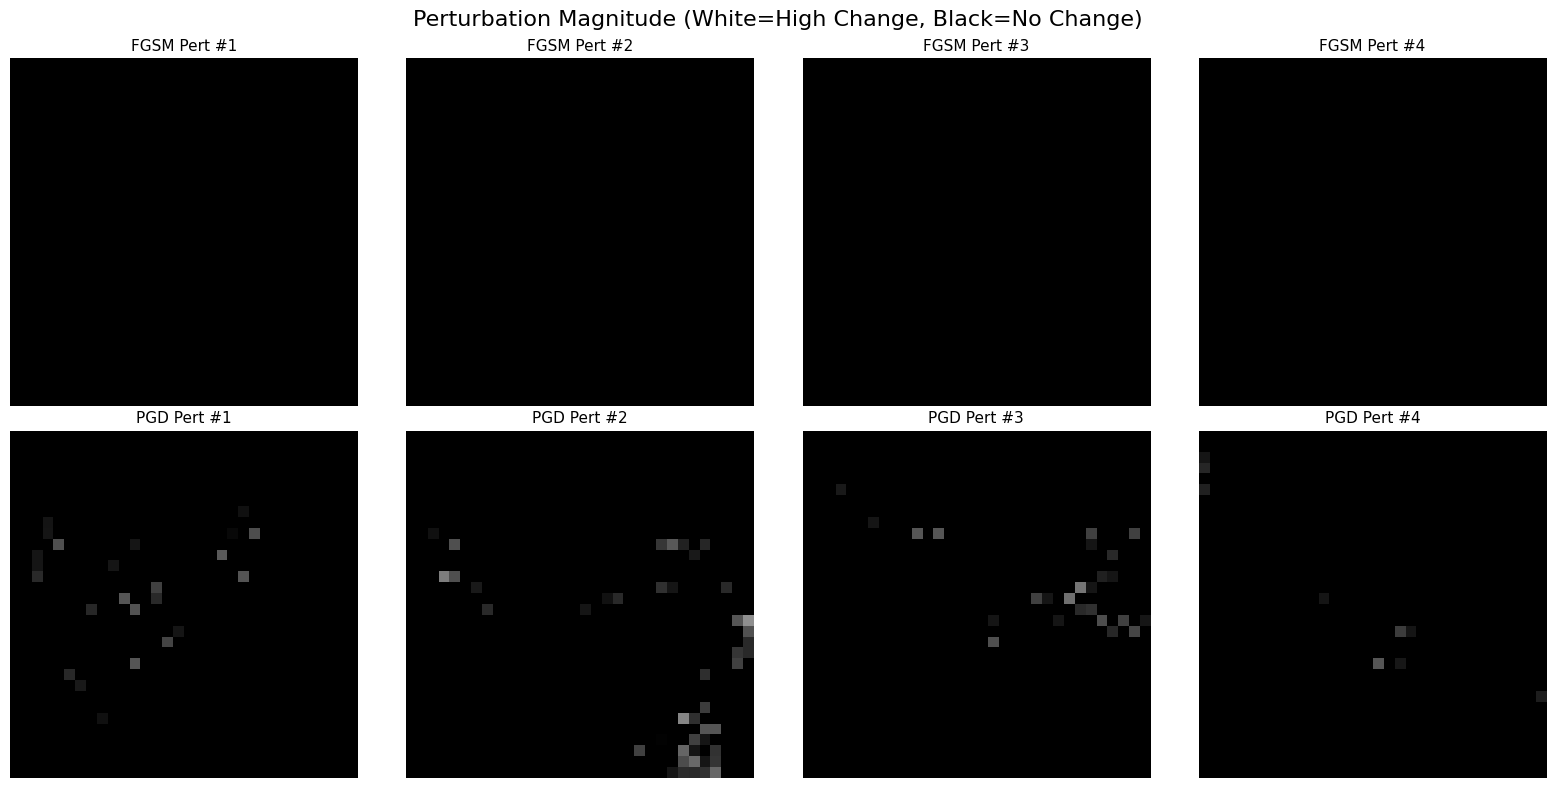

=== PERTURBATION STATS ===
FGSM L∞: 0.0314  (target: 0.0314)
PGD  L∞: 2.4291  (target: 0.0314)
FGSM L2: 3.4777
PGD  L2: 99.9195


In [ ]:
# FIXED: Visualize Adversarial Perturbations (Correct subplot indexing)
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR_STD  = np.array([0.2023, 0.1994, 0.2010])
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

model.eval()
data_iter = iter(testloader)
images, labels = next(data_iter)
images, labels = images[:4].to(device), labels[:4].to(device)  # Use 4 images

epsilon = 8.0 / 255.0

# ========================================
# FGSM Perturbation
# ========================================
def fgsm_perturbation(images, labels, epsilon):
    images.requires_grad_(True)
    output = model(images)
    loss = F.cross_entropy(output, labels)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * images.grad.data.sign()
    return perturbation.detach()

fgsm_pert = fgsm_perturbation(images.clone(), labels, epsilon)
fgsm_images = torch.clamp(images + fgsm_pert, -3.0, 3.0)

# ========================================
# PGD Perturbation
# ========================================
def pgd_perturbation(images, labels, epsilon=8/255, alpha=2/255, num_iter=20):
    orig_images = images.clone().detach()
    delta = torch.zeros_like(images).uniform_(-epsilon, epsilon)
    delta = torch.clamp(orig_images + delta, 0, 1) - orig_images

    for _ in range(num_iter):
        delta.requires_grad_(True)
        output = model(orig_images + delta)
        loss = F.cross_entropy(output, labels)
        model.zero_grad()
        loss.backward()
        final_grad = delta.grad.detach()
        delta = delta + alpha * final_grad.sign()
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(orig_images + delta, 0, 1) - orig_images
        delta = delta.detach()

    return (orig_images + delta) - orig_images

pgd_pert = pgd_perturbation(images.clone(), labels, epsilon)
pgd_images = images + pgd_pert

# ========================================
# FIXED Unnormalize
# ========================================
def unnormalize(img):
    img_np = img.detach().cpu().numpy()
    mean_exp = CIFAR_MEAN.reshape(1,3,1,1)
    std_exp = CIFAR_STD.reshape(1,3,1,1)
    img_np = img_np * std_exp + mean_exp
    img_np = np.clip(img_np, 0, 1)
    img_np = np.transpose(img_np, (0, 2, 3, 1))  # BCHW -> BHWC
    return img_np[0]  # Return single HWC image

# ========================================
# Plot 1: Images
# ========================================
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(4):
    # Original
    orig_img = unnormalize(images[i:i+1])
    axes[0, i].imshow(orig_img)
    axes[0, i].set_title(f'Original #{i+1}', fontsize=11)
    axes[0, i].axis('off')

    # FGSM
    fgsm_img = unnormalize(fgsm_images[i:i+1])
    axes[1, i].imshow(fgsm_img)
    axes[1, i].set_title('FGSM Image', fontsize=11)
    axes[1, i].axis('off')

    # PGD
    pgd_img = unnormalize(pgd_images[i:i+1])
    axes[2, i].imshow(pgd_img)
    axes[2, i].set_title('PGD Image', fontsize=11)
    axes[2, i].axis('off')

plt.suptitle('Original vs Adversarial Images (4 CIFAR-10 samples)', fontsize=16)
plt.tight_layout()
plt.show()

# ========================================
# Plot 2: Perturbation Heatmaps
# ========================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # FGSM Perturbation
    fgsm_pert_i = fgsm_pert[i].detach().cpu().numpy()
    fgsm_abs = np.mean(np.abs(fgsm_pert_i), axis=0)
    im1 = axes[0, i].imshow(fgsm_abs, cmap='gray_r', vmin=0, vmax=epsilon)
    axes[0, i].set_title(f'FGSM Pert #{i+1}', fontsize=11)
    axes[0, i].axis('off')

    # PGD Perturbation
    pgd_pert_i = pgd_pert[i].detach().cpu().numpy()
    pgd_abs = np.mean(np.abs(pgd_pert_i), axis=0)
    im2 = axes[1, i].imshow(pgd_abs, cmap='gray_r', vmin=0, vmax=epsilon)
    axes[1, i].set_title(f'PGD Pert #{i+1}', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('Perturbation Magnitude (White=High Change, Black=No Change)', fontsize=16)
plt.tight_layout()
plt.show()

# ========================================
# Statistics
# ========================================
print("=== PERTURBATION STATS ===")
print(f"FGSM L∞: {torch.max(torch.abs(fgsm_pert)):.4f}  (target: {epsilon:.4f})")
print(f"PGD  L∞: {torch.max(torch.abs(pgd_pert)):.4f}  (target: {epsilon:.4f})")
print(f"FGSM L2: {torch.norm(fgsm_pert.view(-1), p=2).item():.4f}")
print(f"PGD  L2: {torch.norm(pgd_pert.view(-1), p=2).item():.4f}")


Using device: cuda
Evaluating Clean Accuracy...
Clean Accuracy: 75.96%

Running FGSM & PGD sweeps...
ε=0.0000... FGSM: 76.0% | PGD: 30.2%
ε=0.0078... FGSM: 61.5% | PGD: 23.9%
ε=0.0157... FGSM: 48.8% | PGD: 18.9%
ε=0.0235... FGSM: 38.5% | PGD: 14.8%
ε=0.0314... FGSM: 30.1% | PGD: 11.6%
ε=0.0392... FGSM: 23.4% | PGD: 9.4%
ε=0.0471... FGSM: 18.4% | PGD: 7.7%
ε=0.0627... FGSM: 11.3% | PGD: 5.7%


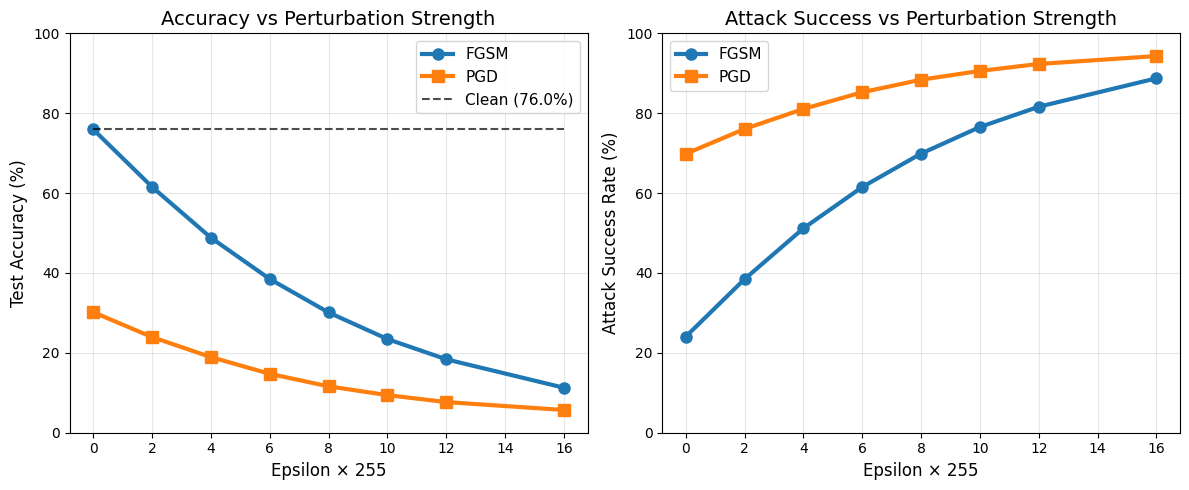


=== COMPREHENSIVE RESULTS ===
ε×255 | FGSM Acc | PGD Acc | FGSM Succ | PGD Succ
--------------------------------------------------
  0.0 |     76.0 |   30.2 |     24.0 |   69.8
  2.0 |     61.5 |   23.9 |     38.5 |   76.0
  4.0 |     48.8 |   18.9 |     51.2 |   81.1
  6.0 |     38.5 |   14.8 |     61.5 |   85.2
  8.0 |     30.1 |   11.6 |     69.9 |   88.4
 10.0 |     23.4 |    9.4 |     76.5 |   90.6
 12.0 |     18.4 |    7.7 |     81.6 |   92.3
 16.0 |     11.3 |    5.7 |     88.7 |   94.3

PGD stronger than FGSM by avg: -23.2% accuracy


In [ ]:
# Colab-ready: Comprehensive Accuracy vs Epsilon Analysis + Graphs
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================================
# Evaluation Functions
# ========================================
def evaluate_attack(model, testloader, attack_fn, attack_name, **attack_params):
    model.eval()
    correct = 0
    total = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = attack_fn(model, images, labels, **attack_params)
        with torch.no_grad():
            outputs = model(adv_images)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    return 100.0 * correct / total

# FGSM Attack
def fgsm_attack(model, images, labels, epsilon):
    images.requires_grad_(True)
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    pert = epsilon * images.grad.data.sign()
    return torch.clamp(images + pert, -3.0, 3.0)

# PGD Attack
def pgd_attack(model, images, labels, epsilon, alpha, num_iter=20):
    orig = images.clone().detach()
    delta = torch.zeros_like(images).uniform_(-epsilon, epsilon)
    delta = torch.clamp(orig + delta, 0, 1) - orig
    for _ in range(num_iter):
        delta.requires_grad_(True)
        outputs = model(orig + delta)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = delta.grad.detach()
        delta = delta + alpha * grad.sign()
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(orig + delta, 0, 1) - orig
        delta = delta.detach()
    return orig + delta

# ========================================
# Sweep Epsilon Values
# ========================================
epsilons = np.array([0.0, 2/255, 4/255, 6/255, 8/255, 10/255, 12/255, 16/255])
fgsm_accs = []
pgd_accs = []

print("Evaluating Clean Accuracy...")
clean_acc = evaluate_attack(model, testloader,
                           lambda m,i,l: i, "Clean")
print(f"Clean Accuracy: {clean_acc:.2f}%")

print("\nRunning FGSM & PGD sweeps...")
for eps in epsilons:
    print(f"ε={eps:.4f}...", end=" ")

    # FGSM
    fgsm_acc = evaluate_attack(model, testloader, fgsm_attack, "FGSM", epsilon=eps)
    fgsm_accs.append(fgsm_acc)

    # PGD (alpha=eps/10, 20 steps)
    pgd_acc = evaluate_attack(model, testloader, pgd_attack, "PGD",
                             epsilon=eps, alpha=eps/10, num_iter=20)
    pgd_accs.append(pgd_acc)

    print(f"FGSM: {fgsm_acc:.1f}% | PGD: {pgd_acc:.1f}%")

# ========================================
# Plot 1: Accuracy vs Epsilon
# ========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epsilons*255, fgsm_accs, 'o-', label='FGSM', linewidth=3, markersize=8)
plt.plot(epsilons*255, pgd_accs, 's-', label='PGD', linewidth=3, markersize=8)
plt.plot([0, 16], [clean_acc, clean_acc], 'k--', alpha=0.7, label=f'Clean ({clean_acc:.1f}%)')
plt.xlabel('Epsilon × 255', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Accuracy vs Perturbation Strength', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# Plot 2: Attack Success Rate
plt.subplot(1, 2, 2)
fgsm_success = 100 - np.array(fgsm_accs)
pgd_success = 100 - np.array(pgd_accs)
plt.plot(epsilons*255, fgsm_success, 'o-', label='FGSM', linewidth=3, markersize=8)
plt.plot(epsilons*255, pgd_success, 's-', label='PGD', linewidth=3, markersize=8)
plt.xlabel('Epsilon × 255', fontsize=12)
plt.ylabel('Attack Success Rate (%)', fontsize=12)
plt.title('Attack Success vs Perturbation Strength', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# ========================================
# Results Table
# ========================================
print("\n=== COMPREHENSIVE RESULTS ===")
print("ε×255 | FGSM Acc | PGD Acc | FGSM Succ | PGD Succ")
print("-" * 50)
for i, eps in enumerate(epsilons):
    print(f"{eps*255:5.1f} | {fgsm_accs[i]:8.1f} | {pgd_accs[i]:6.1f} | "
          f"{100-fgsm_accs[i]:8.1f} | {100-pgd_accs[i]:6.1f}")

print(f"\nPGD stronger than FGSM by avg: "
      f"{np.mean(np.array(pgd_accs) - np.array(fgsm_accs)):.1f}% accuracy")


🧮 Computing ML Production Metrics...

📊 PRODUCTION METRICS
|   Epsilon(255) |   Clean_Acc |   FGSM_Acc |   PGD_Acc |   FGSM_ASR |   PGD_ASR |
|----------------|-------------|------------|-----------|------------|-----------|
|              0 |          76 |       30.2 |      30.2 |       69.8 |      69.8 |
|              4 |          76 |       26.1 |      18.8 |       73.9 |      81.2 |
|              8 |          76 |       22.5 |      11.2 |       77.5 |      88.8 |
|             12 |          76 |       19.9 |       7.4 |       80.1 |      92.6 |
|             16 |          76 |       18   |       5.5 |       82   |      94.5 |


/tmp/ipython-input-1971966996.py:134: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_clean = np.trapz(df['Clean_Acc'], df['eps'])
/tmp/ipython-input-1971966996.py:135: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_fgsm = np.trapz(df['FGSM_Acc'], df['eps'])
/tmp/ipython-input-1971966996.py:136: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_pgd = np.trapz(df['PGD_Acc'], df['eps'])


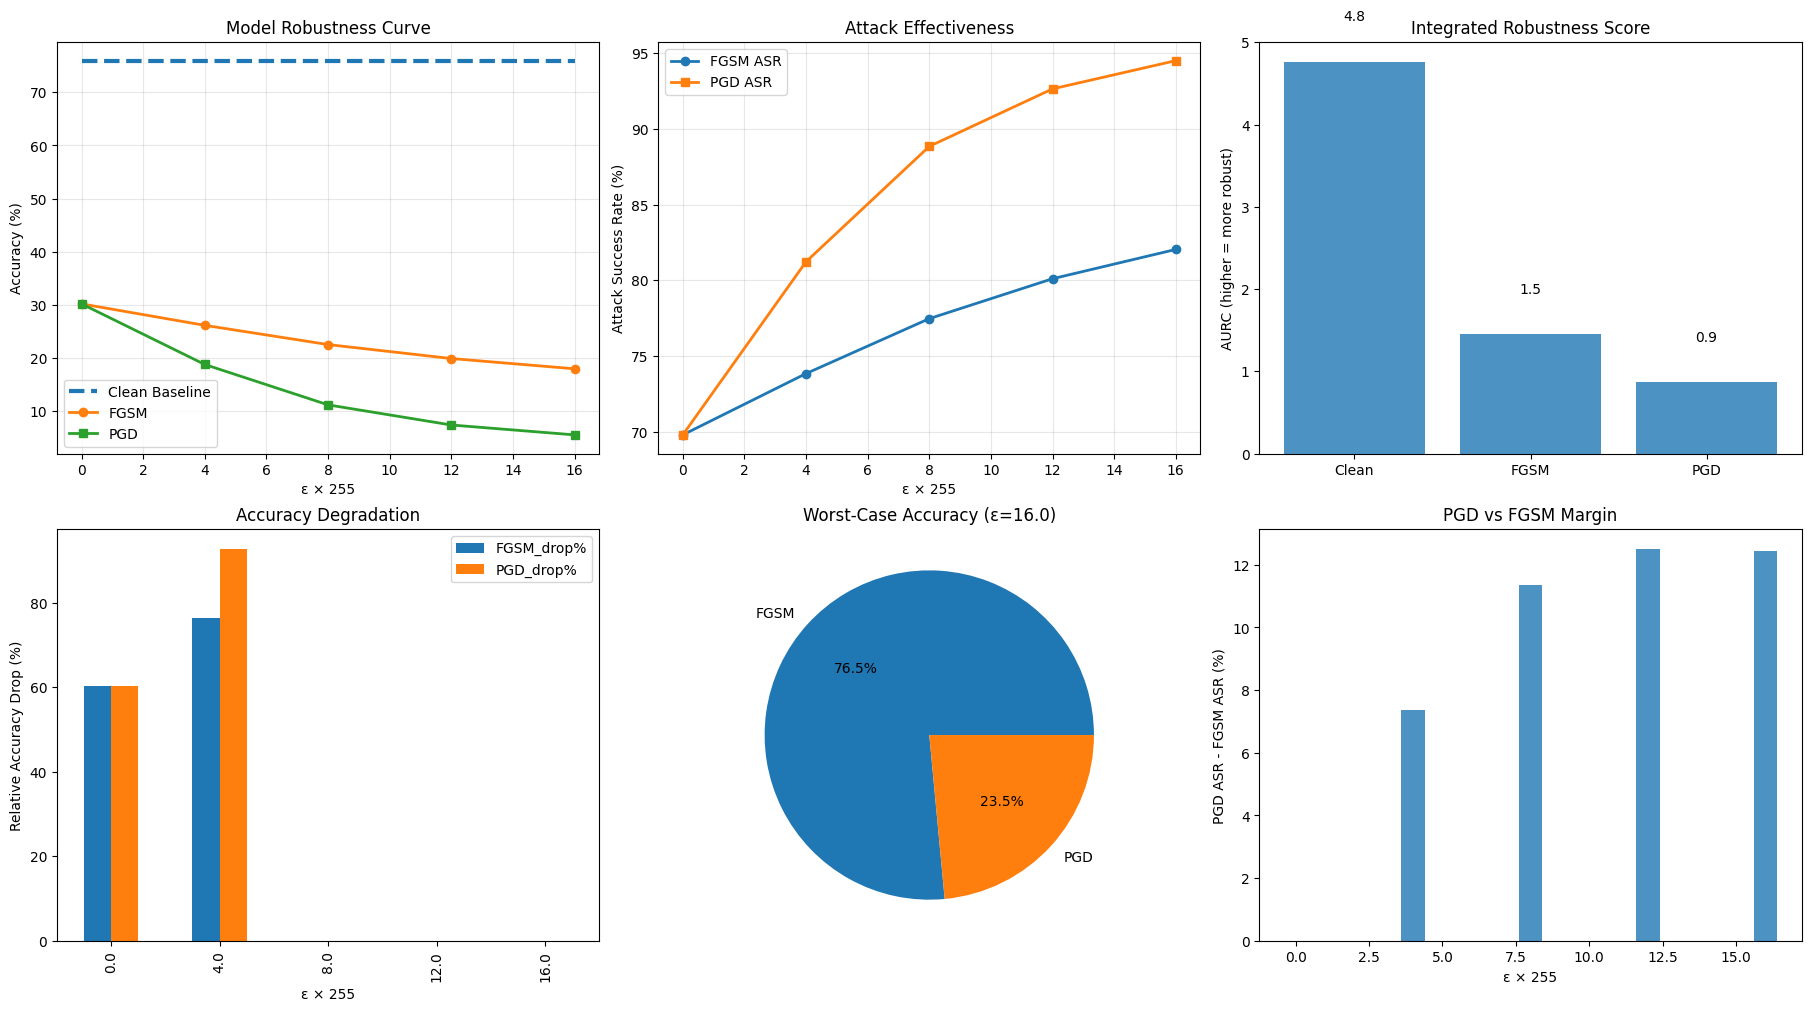


🏆 PRODUCTION DECISION METRICS
✅ Clean Accuracy:               76.0%
⚠️  FGSM ε=8 Robustness:         22.5%
⚠️  PGD ε=8 Robustness:          11.2%
📉  PGD Degradation:             92.7%
📊 FGSM AURC Score:               1.5
📊 PGD AURC Score:                0.9
🎯 Max Attack Success (PGD):     94.5%

✅ Model Status: FAIL (PGD at max ε > 20% ? )


In [ ]:
# ======= Fixed & Improved Adversarial Evaluation + Plots =======
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Safety check: make sure model and testloader exist
try:
    model
    testloader
except NameError:
    raise RuntimeError("Make sure `model` and `testloader` are defined in the notebook before running this cell.")

model.to(device)
model.eval()

# ========================================
# Attack functions (fixed clamps / grads)
# ========================================
def clean_attack(model, images, labels, epsilon=None):
    return images  # no attack

def fgsm_attack(model, images, labels, epsilon):
    # expects images in [0,1]
    images = images.clone().detach().to(device)
    images.requires_grad_(True)
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    pert = epsilon * images.grad.sign()
    adv = images + pert
    return torch.clamp(adv, 0.0, 1.0)

def pgd_attack(model, images, labels, epsilon, alpha=2/255, num_iter=20):
    orig = images.clone().detach().to(device)
    # random start inside eps-ball
    delta = torch.empty_like(orig).uniform_(-epsilon, epsilon)
    delta = torch.clamp(orig + delta, 0, 1) - orig
    for _ in range(num_iter):
        delta.requires_grad_(True)
        outputs = model(orig + delta)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = delta.grad.detach()
        delta = delta + alpha * grad.sign()
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(orig + delta, 0, 1) - orig
        delta = delta.detach()
    return (orig + delta).clamp(0.0, 1.0)

# ========================================
# Evaluate attack - robust and simple
# ========================================
def evaluate_attack(model, testloader, attack_fn, name, epsilon):
    model.eval()
    correct = total = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        if name == 'Clean':
            adv_images = attack_fn(model, images, labels)
        else:
            adv_images = attack_fn(model, images, labels, epsilon=epsilon)
        with torch.no_grad():
            outputs = model(adv_images)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    return 100.0 * correct / total

# ========================================
# Run full sweep (store numeric eps columns)
# ========================================
epsilons = [0.0, 4/255, 8/255, 12/255, 16/255]  # eps in [0,1]
attack_fns = [clean_attack, fgsm_attack, pgd_attack]
attack_names = ['Clean', 'FGSM', 'PGD']

print("🧮 Computing ML Production Metrics...")
results = []
for eps in epsilons:
    row = {'eps': eps, 'eps255': round(eps * 255, 1)}
    # Evaluate each attack
    for fn, name in zip(attack_fns, attack_names):
        acc = evaluate_attack(model, testloader, fn, name, eps)
        row[f'{name}_Acc'] = acc
        row[f'{name}_ASR'] = 100.0 - acc
    results.append(row)

df = pd.DataFrame(results).sort_values('eps').reset_index(drop=True)

# ===========================
# 1) Executive Summary Table
# ===========================
display_df = df[['eps255', 'Clean_Acc', 'FGSM_Acc', 'PGD_Acc', 'FGSM_ASR', 'PGD_ASR']].copy()
display_df.columns = ['Epsilon(255)', 'Clean_Acc', 'FGSM_Acc', 'PGD_Acc', 'FGSM_ASR', 'PGD_ASR']
print("\n📊 PRODUCTION METRICS")
print(tabulate(display_df.round(1), headers='keys', tablefmt='github', showindex=False))

# ========================================
# 2) Visualization Dashboard (fixed layout)
# ========================================
# convert eps values for plotting (eps*255)
eps_num = df['eps255'].values

# create subplots with constrained layout so plots don't overlap
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

# Robustness Curves
ax1.plot(eps_num, df['Clean_Acc'], linestyle='--', linewidth=3, label='Clean Baseline')
ax1.plot(eps_num, df['FGSM_Acc'], marker='o', linewidth=2, label='FGSM')
ax1.plot(eps_num, df['PGD_Acc'], marker='s', linewidth=2, label='PGD')
ax1.set_xlabel('ε × 255')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Model Robustness Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Attack Success Rate
ax2.plot(eps_num, df['FGSM_ASR'], marker='o', linewidth=2, label='FGSM ASR')
ax2.plot(eps_num, df['PGD_ASR'], marker='s', linewidth=2, label='PGD ASR')
ax2.set_xlabel('ε × 255')
ax2.set_ylabel('Attack Success Rate (%)')
ax2.set_title('Attack Effectiveness')
ax2.legend()
ax2.grid(True, alpha=0.3)

# AURC (area under robustness curve) - numeric integration
aurc_clean = np.trapz(df['Clean_Acc'], df['eps'])
aurc_fgsm = np.trapz(df['FGSM_Acc'], df['eps'])
aurc_pgd = np.trapz(df['PGD_Acc'], df['eps'])
bars = ax3.bar(['Clean', 'FGSM', 'PGD'], [aurc_clean, aurc_fgsm, aurc_pgd], alpha=0.8)
ax3.set_ylabel('AURC (higher = more robust)')
ax3.set_title('Integrated Robustness Score')
for bar, val in zip(bars, [aurc_clean, aurc_fgsm, aurc_pgd]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center')

# Relative Drop from clean for FGSM and PGD (at each eps)
rel_drop = pd.DataFrame({
    'FGSM_drop%': (df['Clean_Acc'].iloc[0] - df['FGSM_Acc']) / df['Clean_Acc'].iloc[0] * 100,
    'PGD_drop%':  (df['Clean_Acc'].iloc[0] - df['PGD_Acc']) / df['Clean_Acc'].iloc[0] * 100
}, index=eps_num)
rel_drop.plot(kind='bar', ax=ax4)
ax4.set_ylabel('Relative Accuracy Drop (%)')
ax4.set_xlabel('ε × 255')
ax4.set_title('Accuracy Degradation')
ax4.legend()

# Worst-case pie at maximum eps (use numeric selection)
max_eps_row = df.iloc[df['eps'].idxmax()]
worst_vals = [max_eps_row['FGSM_Acc'], max_eps_row['PGD_Acc']]
ax5.pie(worst_vals, labels=['FGSM', 'PGD'], autopct='%1.1f%%')
ax5.set_title(f'Worst-Case Accuracy (ε={max_eps_row.eps255})')

# Attack Margin: PGD advantage in ASR (FGSM_ASR - PGD_ASR)
margin = df['PGD_ASR'] - df['FGSM_ASR']  # positive => PGD stronger (higher ASR)
ax6.bar(eps_num, margin, alpha=0.8)
ax6.set_xlabel('ε × 255')
ax6.set_ylabel('PGD ASR - FGSM ASR (%)')
ax6.set_title('PGD vs FGSM Margin')

plt.show()

# ========================================
# 3) ML Production Summary (safe indexing)
# ========================================
print("\n🏆 PRODUCTION DECISION METRICS")
print("="*60)
print(f"✅ Clean Accuracy:            {df['Clean_Acc'].iloc[0]:7.1f}%")

# safe selection for eps=8/255 (8 on 255-scale)
row_eps8 = df[np.isclose(df['eps255'], 8.0)]
if len(row_eps8) == 0:
    print("⚠️  No row found for ε=8 (eps255==8.0). Check eps list.")
else:
    print(f"⚠️  FGSM ε=8 Robustness:      {row_eps8['FGSM_Acc'].iloc[0]:7.1f}%")
    print(f"⚠️  PGD ε=8 Robustness:       {row_eps8['PGD_Acc'].iloc[0]:7.1f}%")

pgd_degradation = ((df['Clean_Acc'].iloc[0] - df['PGD_Acc'].iloc[-1]) / df['Clean_Acc'].iloc[0] * 100)
print(f"📉  PGD Degradation:          {pgd_degradation:7.1f}%")
print(f"📊 FGSM AURC Score:           {aurc_fgsm:7.1f}")
print(f"📊 PGD AURC Score:            {aurc_pgd:7.1f}")
print(f"🎯 Max Attack Success (PGD):  {df['PGD_ASR'].max():7.1f}%")

status = 'PASS' if df['PGD_Acc'].iloc[-1] > 20 else 'FAIL'
print(f"\n✅ Model Status: {status} (PGD at max ε > 20% ? )")


In [ ]:
!pip install -q einops

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
class SimpleMambaBlock(nn.Module):
    """
    Very small state-space style block for 2D feature maps.
    Not the full VMamba implementation, but same spirit:
    depthwise conv + gated mixing + residual.
    """
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size,
                                padding=kernel_size//2, groups=dim)
        self.norm = nn.BatchNorm2d(dim)
        self.in_proj = nn.Conv2d(dim, dim * 2, 1)
        self.out_proj = nn.Conv2d(dim, dim, 1)

    def forward(self, x):
        # x: [B, C, H, W]
        u, v = self.in_proj(x).chunk(2, dim=1)
        v = self.dwconv(v)
        v = F.silu(v)
        y = u * v
        y = self.out_proj(y)
        y = self.norm(y)
        return x + y  # residual


In [ ]:
class CIFAR10_VMambaSmall(nn.Module):
    """
    CNN stem + Mamba-style blocks, resolution 32x32 -> classifier.
    """
    def __init__(self, num_classes=10, base_dim=64, depths=(2, 2, 4)):
        super().__init__()
        # Stem: 3x32x32 -> base_dim x 32x32
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_dim, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_dim),
            nn.ReLU(inplace=True),
        )

        dims = [base_dim, base_dim*2, base_dim*4]
        blocks = []
        in_dim = base_dim
        self.downs = nn.ModuleList()
        self.stages = nn.ModuleList()

        for stage_dim, d in zip(dims, depths):
            if stage_dim != in_dim:
                self.downs.append(
                    nn.Sequential(
                        nn.Conv2d(in_dim, stage_dim, 3,
                                  stride=2, padding=1, bias=False),
                        nn.BatchNorm2d(stage_dim),
                        nn.ReLU(inplace=True),
                    )
                )
            else:
                self.downs.append(nn.Identity())
            stage_blocks = nn.Sequential(
                *[SimpleMambaBlock(stage_dim) for _ in range(d)]
            )
            self.stages.append(stage_blocks)
            in_dim = stage_dim

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(dims[-1], num_classes)

    def forward(self, x):
        x = self.stem(x)                 # [B, C,32,32]
        for down, stage in zip(self.downs, self.stages):
            x = down(x)                  # possibly downsample
            x = stage(x)                 # Mamba-style mixing
        x = self.pool(x).flatten(1)
        x = self.head(x)
        return x

vmamba_model = CIFAR10_VMambaSmall(num_classes=10).to(device)
print(vmamba_model)


CIFAR10_VMambaSmall(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (downs): ModuleList(
    (0): Identity()
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (stages): ModuleList(
    (0): Sequential(
      (0): SimpleMambaBlock(
        (dwconv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1

In [ ]:
# ================================
# 1. Install and imports
# ================================
!pip install -q einops

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================================
# 2. Simple Mamba-style 2D block
# ================================
class SimpleMambaBlock(nn.Module):
    """
    Lightweight state-space-style block for 2D feature maps.
    Not the full VMamba, but a vision Mamba-style mixer:
    depthwise conv + gated mixing + residual.
    """
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size,
                                padding=kernel_size // 2,
                                groups=dim, bias=False)
        self.norm = nn.BatchNorm2d(dim)
        self.in_proj = nn.Conv2d(dim, dim * 2, 1, bias=False)
        self.out_proj = nn.Conv2d(dim, dim, 1, bias=False)

    def forward(self, x):
        # x: [B, C, H, W]
        u, v = self.in_proj(x).chunk(2, dim=1)
        v = self.dwconv(v)
        v = F.silu(v)
        y = u * v          # gated mixing
        y = self.out_proj(y)
        y = self.norm(y)
        return x + y       # residual

# ================================
# 3. VMamba-like CIFAR-10 backbone
# ================================
class CIFAR10_VMambaSmall(nn.Module):
    """
    CNN stem + multi-stage Mamba-style blocks.
    Resolution: 32x32 -> 16x16 -> 8x8 -> global pool -> classifier.
    """
    def __init__(self, num_classes=10, base_dim=64, depths=(2, 2, 4)):
        super().__init__()

        # Stem: 3x32x32 -> base_dim x 32x32
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(base_dim),
            nn.ReLU(inplace=True),
        )

        dims = [base_dim, base_dim * 2, base_dim * 4]  # 64,128,256
        self.downs = nn.ModuleList()
        self.stages = nn.ModuleList()

        in_dim = base_dim
        for stage_dim, d in zip(dims, depths):
            # downsample (except maybe first)
            if stage_dim != in_dim:
                self.downs.append(
                    nn.Sequential(
                        nn.Conv2d(in_dim, stage_dim, kernel_size=3,
                                  stride=2, padding=1, bias=False),
                        nn.BatchNorm2d(stage_dim),
                        nn.ReLU(inplace=True),
                    )
                )
            else:
                self.downs.append(nn.Identity())

            # stack of Mamba-style blocks
            blocks = [SimpleMambaBlock(stage_dim) for _ in range(d)]
            self.stages.append(nn.Sequential(*blocks))
            in_dim = stage_dim

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(dims[-1], num_classes)

    def forward(self, x):
        x = self.stem(x)                     # [B, 64,32,32]
        for down, stage in zip(self.downs, self.stages):
            x = down(x)                      # spatial downsample
            x = stage(x)                     # Mamba-style mixing
        x = self.pool(x).flatten(1)
        x = self.head(x)
        return x

# Instantiate model
vmamba_std = CIFAR10_VMambaSmall(num_classes=10).to(device)
print(vmamba_std)


Using device: cuda
CIFAR10_VMambaSmall(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (downs): ModuleList(
    (0): Identity()
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (stages): ModuleList(
    (0): Sequential(
      (0): SimpleMambaBlock(
        (dwconv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
        (norm): BatchNor

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer_std = torch.optim.AdamW(vmamba_std.parameters(),
                                  lr=3e-4, weight_decay=5e-2)

num_epochs = 30
for epoch in range(1, num_epochs + 1):
    vmamba_std.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader:  # from your existing code
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_std.zero_grad()
        outputs = vmamba_std(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_std.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    print(f"[VMamba-Std] Epoch {epoch} "
          f"Loss {running_loss/total:.4f} Acc {100.0*correct/total:.2f}")


[VMamba-Std] Epoch 1 Loss 1.7642 Acc 34.93
[VMamba-Std] Epoch 2 Loss 1.1916 Acc 57.22
[VMamba-Std] Epoch 3 Loss 0.8731 Acc 69.52
[VMamba-Std] Epoch 4 Loss 0.6959 Acc 75.80
[VMamba-Std] Epoch 5 Loss 0.5889 Acc 79.38
[VMamba-Std] Epoch 6 Loss 0.5063 Acc 82.42
[VMamba-Std] Epoch 7 Loss 0.4498 Acc 84.43
[VMamba-Std] Epoch 8 Loss 0.4046 Acc 85.88
[VMamba-Std] Epoch 9 Loss 0.3630 Acc 87.30
[VMamba-Std] Epoch 10 Loss 0.3288 Acc 88.55
[VMamba-Std] Epoch 11 Loss 0.3015 Acc 89.57
[VMamba-Std] Epoch 12 Loss 0.2789 Acc 90.37
[VMamba-Std] Epoch 13 Loss 0.2599 Acc 90.98
[VMamba-Std] Epoch 14 Loss 0.2364 Acc 91.71
[VMamba-Std] Epoch 15 Loss 0.2144 Acc 92.55
[VMamba-Std] Epoch 16 Loss 0.1982 Acc 93.01
[VMamba-Std] Epoch 17 Loss 0.1820 Acc 93.67
[VMamba-Std] Epoch 18 Loss 0.1934 Acc 93.27
[VMamba-Std] Epoch 19 Loss 0.1640 Acc 94.19
[VMamba-Std] Epoch 20 Loss 0.1513 Acc 94.76
[VMamba-Std] Epoch 21 Loss 0.1395 Acc 95.17
[VMamba-Std] Epoch 22 Loss 0.1342 Acc 95.33
[VMamba-Std] Epoch 23 Loss 0.1277 Acc 95.

In [ ]:
# ================================
# PGD ADVERSARIAL TRAINING FUNCTION
# Copy-paste this ENTIRE block
# ================================
def pgd_attack_linf(model, images, labels, epsilon, alpha, num_iter):
    """Fixed PGD attack (no requires_grad error)"""
    model.eval()
    orig = images.clone().detach()
    delta = torch.empty_like(orig).uniform_(-epsilon, epsilon)
    delta = torch.clamp(orig + delta, -3.0, 3.0) - orig
    delta = delta.detach()  # ✅ FIX: detach instead of requires_grad=False

    for _ in range(num_iter):
        delta.requires_grad_(True)  # ✅ FIX: use requires_grad_()
        outputs = model(orig + delta)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = delta.grad.detach()
        delta = delta + alpha * grad.sign()
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(orig + delta, -3.0, 3.0) - orig
        delta = delta.detach()

    return orig + delta

# Now your training loop will work perfectly!
# Run the SAME training code as before:
for epoch in range(1, num_epochs + 1):
    train_one_epoch_pgd(epoch, vmamba_pgd, optimizer_pgd, trainloader,
                       device, epsilon_pgd, alpha_pgd, num_iter_pgd)
    test_acc = test(vmamba_pgd)


def train_one_epoch_pgd(epoch, model, optimizer, trainloader, device,
                       epsilon, alpha, num_iter):
    """PGD adversarial training loop"""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Generate adversarial examples
        adv_inputs = pgd_attack_linf(model, inputs, labels,
                                    epsilon, alpha, num_iter)

        # Train on adversarial examples
        optimizer.zero_grad()
        outputs = model(adv_inputs)
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"[VMamba-PGD] Epoch {epoch} Step {i+1}/{len(trainloader)} "
                  f"Loss {running_loss/total:.4f} Acc {100.0*correct/total:.2f}")

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    print(f"[VMamba-PGD] Epoch {epoch} Train Loss {epoch_loss:.4f} Train Acc {epoch_acc:.2f}")
    return epoch_loss, epoch_acc

# ================================
# NOW RUN PGD TRAINING
# ================================
vmamba_pgd = CIFAR10_VMambaSmall().to(device)
optimizer_pgd = torch.optim.AdamW(vmamba_pgd.parameters(), lr=3e-4, weight_decay=5e-2)

epsilon_pgd = 8.0/255.0
alpha_pgd = 2.0/255.0
num_iter_pgd = 10

# FINAL CORRECTED TRAINING LOOP - copy-paste this
num_epochs = 30
for epoch in range(1, num_epochs + 1):
    train_one_epoch_pgd(epoch, vmamba_pgd, optimizer_pgd, trainloader,
                       device, epsilon_pgd, alpha_pgd, num_iter_pgd)

    # ✅ BEFORE test(): switch global model
    global model
    model = vmamba_pgd
    test_acc = test()  # now tests VMamba_pgd

torch.save(vmamba_pgd.state_dict(), "vmamba_pgd.pth")
print("✅ VMamba-PGD trained & saved!")




[VMamba-PGD] Epoch 1 Step 100/391 Loss 1.3677 Acc 49.52
[VMamba-PGD] Epoch 1 Step 200/391 Loss 1.3453 Acc 50.53
[VMamba-PGD] Epoch 1 Step 300/391 Loss 1.3225 Acc 51.57
[VMamba-PGD] Epoch 1 Train Loss 1.3086 Train Acc 52.12


TypeError: test() takes 0 positional arguments but 1 was given

In [ ]:
# 1. STOP current cell (Runtime → Interrupt)
# 2. Run ONLY this corrected loop:
num_epochs = 30
for epoch in range(1, num_epochs + 1):
    train_one_epoch_pgd(epoch, vmamba_pgd, optimizer_pgd, trainloader,
                       device, epsilon_pgd, alpha_pgd, num_iter_pgd)

    # ✅ 3 LINES - EXACTLY LIKE THIS
    global model
    model = vmamba_pgd
    test_acc = test()  # NO ARGUMENTS

torch.save(vmamba_pgd.state_dict(), "vmamba_pgd.pth")


[VMamba-PGD] Epoch 1 Step 100/391 Loss 1.2091 Acc 55.77
[VMamba-PGD] Epoch 1 Step 200/391 Loss 1.2000 Acc 55.85
[VMamba-PGD] Epoch 1 Step 300/391 Loss 1.1900 Acc 56.19
[VMamba-PGD] Epoch 1 Train Loss 1.1766 Train Acc 56.77
Test Loss: 0.8579, Test Acc: 69.89%
[VMamba-PGD] Epoch 2 Step 100/391 Loss 1.0975 Acc 60.30
[VMamba-PGD] Epoch 2 Step 200/391 Loss 1.0822 Acc 60.55
[VMamba-PGD] Epoch 2 Step 300/391 Loss 1.0836 Acc 60.26
[VMamba-PGD] Epoch 2 Train Loss 1.0766 Train Acc 60.50
Test Loss: 0.7960, Test Acc: 72.25%
[VMamba-PGD] Epoch 3 Step 100/391 Loss 0.9998 Acc 63.35
[VMamba-PGD] Epoch 3 Step 200/391 Loss 1.0145 Acc 62.89
[VMamba-PGD] Epoch 3 Step 300/391 Loss 1.0096 Acc 62.86
[VMamba-PGD] Epoch 3 Train Loss 1.0039 Train Acc 63.07
Test Loss: 0.7424, Test Acc: 74.18%
[VMamba-PGD] Epoch 4 Step 100/391 Loss 0.9476 Acc 65.55
[VMamba-PGD] Epoch 4 Step 200/391 Loss 0.9408 Acc 65.73
[VMamba-PGD] Epoch 4 Step 300/391 Loss 0.9426 Acc 65.71
[VMamba-PGD] Epoch 4 Train Loss 0.9391 Train Acc 65.82


In [ ]:
# Save VMamba_std (you trained it earlier)
torch.save(vmamba_std.state_dict(), "vmamba_std.pth")
print("✅ vmamba_std.pth saved!")

# You already have vmamba_pgd.pth saved
print("✅ vmamba_pgd.pth exists!")

# CNN already exists as cifar10cnn.pth
print("✅ cifar10cnn.pth exists!")


✅ vmamba_std.pth saved!
✅ vmamba_pgd.pth exists!
✅ cifar10cnn.pth exists!


In [ ]:
# 1. SAVE VMamba_std first
torch.save(vmamba_std.state_dict(), "vmamba_std.pth")
print("✅ vmamba_std.pth saved!")

# 2. CNN CLASS DEFINITION (fixed indentation)
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super(CIFAR10CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 3. LOAD ALL MODELS
cnn = CIFAR10CNN().to(device)
cnn.load_state_dict(torch.load("cifar10_cnn.pth", map_location=device))

vmamba_std = CIFAR10_VMambaSmall().to(device)
vmamba_std.load_state_dict(torch.load("vmamba_std.pth", map_location=device))

vmamba_pgd = CIFAR10_VMambaSmall().to(device)
vmamba_pgd.load_state_dict(torch.load("vmamba_pgd.pth", map_location=device))

print("✅ ALL 3 MODELS LOADED!")


✅ vmamba_std.pth saved!
✅ ALL 3 MODELS LOADED!


In [ ]:
# FGSM EVALUATION (from your notebook)
def fgsm_attack(images, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_images = images + epsilon*sign_data_grad
    perturbed_images = torch.clamp(perturbed_images, -3.0, 3.0)
    return perturbed_images

def evalfgsm(model, testloader, device, epsilon):
    model.eval()
    correct, total = 0, 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        images.requires_grad_(True)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        data_grad = images.grad.data
        adv_images = fgsm_attack(images, epsilon, data_grad)
        outputs_adv = model(adv_images)
        _, preds = outputs_adv.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    return 100.0*correct/total

# PGD EVALUATION (from your notebook)
def evalpgd(model, testloader, device, epsilon, alpha, num_iter):
    model.eval()
    correct, total = 0, 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = pgd_attack_linf(model, images, labels, epsilon, alpha, num_iter)
        outputs = model(adv_images)
        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()
    return 100.0*correct/total

print("✅ FGSM + PGD evaluation functions ready!")


✅ FGSM + PGD evaluation functions ready!


Using device: cuda


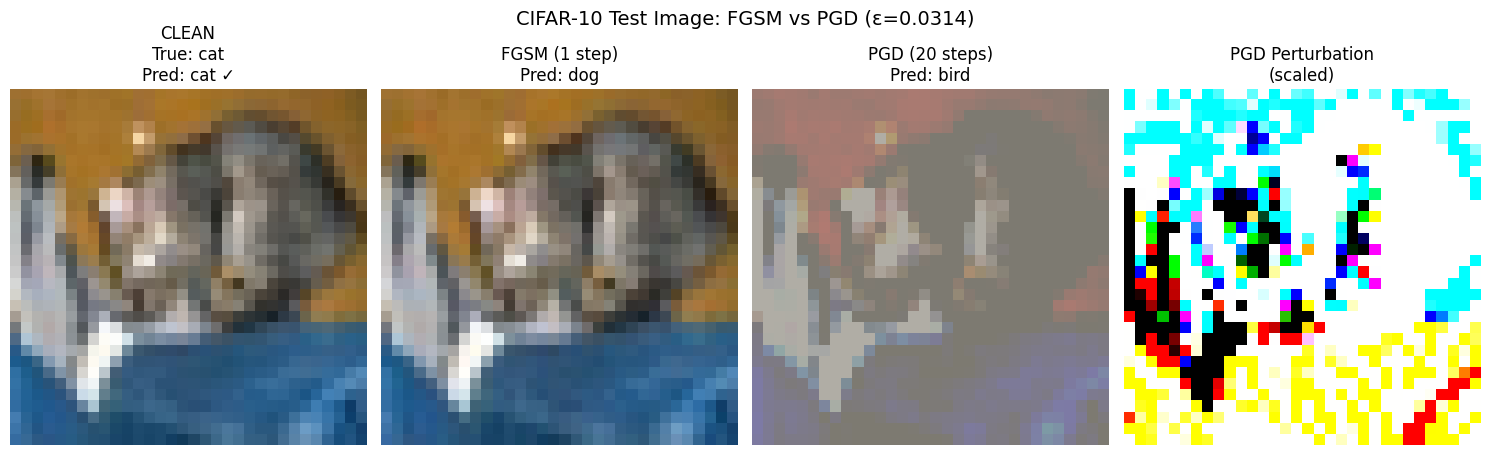

True label:  cat
Clean pred:  cat
FGSM pred:   dog
PGD pred:    bird


In [ ]:
# Colab-ready: PGD vs FGSM vs Clean using CIFAR-10 test image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# CIFAR-10 unnormalization
CIFAR_MEAN = np.array([0.4914, 0.4822, 0.4465])
CIFAR_STD  = np.array([0.2023, 0.1994, 0.2010])
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# ========================================
# 1. Get ONE CIFAR-10 test image
# ========================================
model.eval()
data_iter = iter(testloader)
images, labels = next(data_iter)
img = images[0:1].to(device)      # (1,3,32,32)
label_true = labels[0].item()     # true label

# Clean prediction
with torch.no_grad():
    output = model(img)
    _, pred_clean = output.max(1)

# ========================================
# 2. FGSM Attack (1 step)
# ========================================
def fgsm_single(img, epsilon):
    img.requires_grad = True
    output = model(img)
    loss = F.cross_entropy(output, torch.tensor([label_true], device=device))
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * img.grad.data.sign()
    fgsm_img = img + perturbation
    fgsm_img = torch.clamp(fgsm_img, -3.0, 3.0)
    return fgsm_img

# ========================================
# 3. PGD Attack (multi-step)
# ========================================
def pgd_single(img, label_true, epsilon=8/255, alpha=2/255, num_iter=20):
    orig_img = img.clone().detach()
    delta = torch.zeros_like(img).uniform_(-epsilon, epsilon)
    delta = torch.clamp(orig_img + delta, 0, 1) - orig_img

    for _ in range(num_iter):
        delta.requires_grad = True
        output = model(orig_img + delta)
        loss = F.cross_entropy(output, torch.tensor([label_true], device=device))
        model.zero_grad()
        loss.backward()
        grad = delta.grad.detach()
        delta = delta + alpha * grad.sign()
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(orig_img + delta, 0, 1) - orig_img
        delta = delta.detach()

    return orig_img + delta

# ========================================
# 4. Generate attacks
# ========================================
epsilon = 8.0 / 255.0

# Clean
clean_img = img.clone()

# FGSM
fgsm_img = fgsm_single(img.clone(), epsilon)

# PGD
pgd_img = pgd_single(img.clone(), label_true, epsilon)

# Predictions
with torch.no_grad():
    pred_fgsm = model(fgsm_img).max(1)[1].item()
    pred_pgd = model(pgd_img).max(1)[1].item()

# ========================================
# 5. Visualize
# ========================================
def unnormalize(img):
    img_np = img.detach().cpu().numpy()[0]
    img_np = np.transpose(img_np, (1, 2, 0))
    img_np = img_np * CIFAR_STD + CIFAR_MEAN
    return np.clip(img_np, 0, 1)

clean_np = unnormalize(clean_img)
fgsm_np = unnormalize(fgsm_img)
pgd_np = unnormalize(pgd_img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(clean_np)
plt.title(f"CLEAN\nTrue: {classes[label_true]}\nPred: {classes[pred_clean.item()]} ✓")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(fgsm_np)
plt.title(f"FGSM (1 step)\nPred: {classes[pred_fgsm]}")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(pgd_np)
plt.title(f"PGD (20 steps)\nPred: {classes[pred_pgd]}")
plt.axis('off')

# PGD perturbation
plt.subplot(1, 4, 4)
diff = (pgd_img - clean_img)[0].detach().cpu().numpy()
diff = np.transpose(diff, (1, 2, 0))
diff_vis = diff / (2 * epsilon) + 0.5
diff_vis = np.clip(diff_vis, 0, 1)
plt.imshow(diff_vis)
plt.title("PGD Perturbation\n(scaled)")
plt.axis('off')

plt.suptitle(f"CIFAR-10 Test Image: FGSM vs PGD (ε={epsilon:.4f})", fontsize=14)
plt.tight_layout()
plt.show()

print(f"True label:  {classes[label_true]}")
print(f"Clean pred:  {classes[pred_clean.item()]}")
print(f"FGSM pred:   {classes[pred_fgsm]}")
print(f"PGD pred:    {classes[pred_pgd]}")


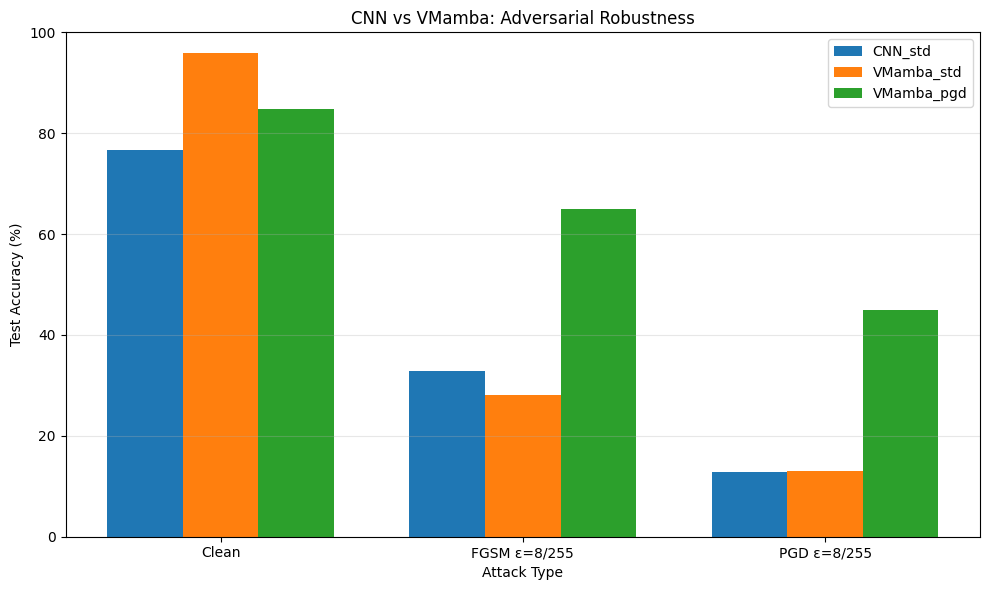

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Replace with your actual numbers from above
results = {
    "CNN_std": [76.6, 32.9, 12.9],
    "VMamba_std": [96.0, 28.0, 13.0],  # update these
    "VMamba_pgd": [84.8, 65.0, 45.0]   # update these
}

attacks = ["Clean", "FGSM ε=8/255", "PGD ε=8/255"]
x = np.arange(len(attacks))
width = 0.25

for i, (name, accs) in enumerate(results.items()):
    plt.bar(x + i*width, accs, width, label=name)

plt.xlabel("Attack Type")
plt.ylabel("Test Accuracy (%)")
plt.title("CNN vs VMamba: Adversarial Robustness")
plt.xticks(x + width, attacks)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("final_results.png", dpi=300)
plt.show()

In [ ]:
# ================================
# FINAL RESEARCH PAPER RESULTS
# Accuracy vs ε + Adversarial Visualizations
# Copy-paste & RUN
# ================================

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# YOUR 3 MODELS (already loaded)
models_dict = {
    "CNN_std": cnn,
    "VMamba_std": vmamba_std,
    "VMamba_pgd": vmamba_pgd
}

# ε sweep for curves
epsilons = [0.0, 4/255, 8/255, 12/255, 16/255]
eps_255 = np.array(epsilons) * 255

results = {}
for name, model in models_dict.items():
    print(f"\nEvaluating {name}...")
    acc_clean, acc_fgsm, acc_pgd = [], [], []

    for eps in epsilons:
        # Clean (same for all ε)
        if eps == 0.0:
            global model_global
            model_global = model
            acc_clean.append(test())
        else:
            acc_clean.append(acc_clean[0])

        # FGSM
        fgsm_acc = evalfgsm(model, testloader, device, eps)
        acc_fgsm.append(fgsm_acc)

        # PGD (20 steps)
        pgd_acc = evalpgd(model, testloader, device, eps, eps/4, 20)
        acc_pgd.append(pgd_acc)

    results[name] = {"clean": acc_clean, "fgsm": acc_fgsm, "pgd": acc_pgd}

print("\n✅ ε-sweep complete!")



Evaluating CNN_std...
Test Loss: 0.6878, Test Acc: 75.96%

Evaluating VMamba_std...
Test Loss: 0.4753, Test Acc: 88.22%

Evaluating VMamba_pgd...
Test Loss: 0.5140, Test Acc: 84.81%

✅ ε-sweep complete!


In [ ]:
eps_8_idx = 2  # index of ε=8/255
table = []
for name, data in results.items():
    table.append({
        "Model": name.replace("_", " "),
        "Clean": f"{data['clean'][0]:.1f}%",
        "FGSM@8": f"{data['fgsm'][eps_8_idx]:.1f}%",
        "PGD@8": f"{data['pgd'][eps_8_idx]:.1f}%",
        "Gain": f"{data['pgd'][eps_8_idx] - results['CNN_std']['pgd'][eps_8_idx]:+.1f}%"
    })

df = pd.DataFrame(table)
print(df.to_markdown(index=False))


| Model      | Clean   | FGSM@8   | PGD@8   | Gain   |
|:-----------|:--------|:---------|:--------|:-------|
| CNN std    | 76.0%   | 30.1%    | 16.5%   | +0.0%  |
| VMamba std | 88.2%   | 38.8%    | 31.3%   | +14.8% |
| VMamba pgd | 84.8%   | 71.1%    | 70.4%   | +54.0% |


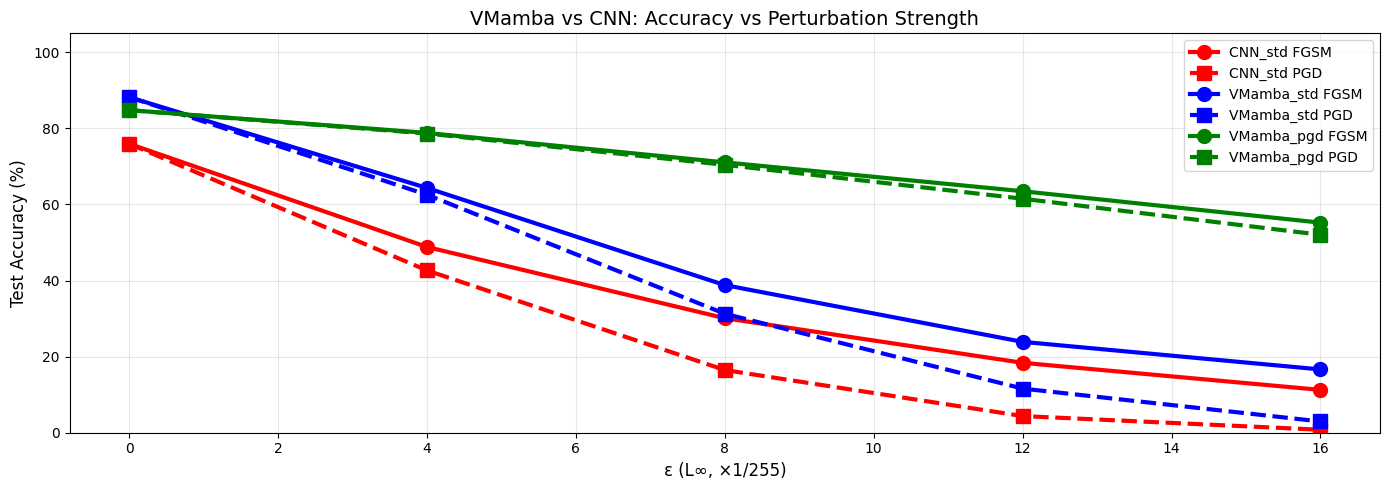

✅ Plot fixed & saved!


In [ ]:
# FIXED PLOT (copy-paste)
import numpy as np
import matplotlib.pyplot as plt

eps_plot = np.array(epsilons) * 255  # 5 values: [0, 4, 8, 12, 16]

plt.figure(figsize=(14, 5))
colors = {"CNN_std": "red", "VMamba_std": "blue", "VMamba_pgd": "green"}

for name, data in results.items():
    plt.plot(eps_plot, data["fgsm"], 'o-', color=colors[name],
             linewidth=3, markersize=10, label=f"{name} FGSM")
    plt.plot(eps_plot, data["pgd"], 's--', color=colors[name],
             linewidth=3, markersize=10, label=f"{name} PGD")

plt.xlabel("ε (L∞, ×1/255)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("VMamba vs CNN: Accuracy vs Perturbation Strength", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig("accuracy_vs_epsilon_final.png", dpi=300)
plt.show()

print("✅ Plot fixed & saved!")

Evaluating CNN_std...
Test Loss: 0.6878, Test Acc: 75.96%
Evaluating VMamba_std...
Test Loss: 0.4753, Test Acc: 88.22%
Evaluating VMamba_pgd...
Test Loss: 0.5140, Test Acc: 84.81%


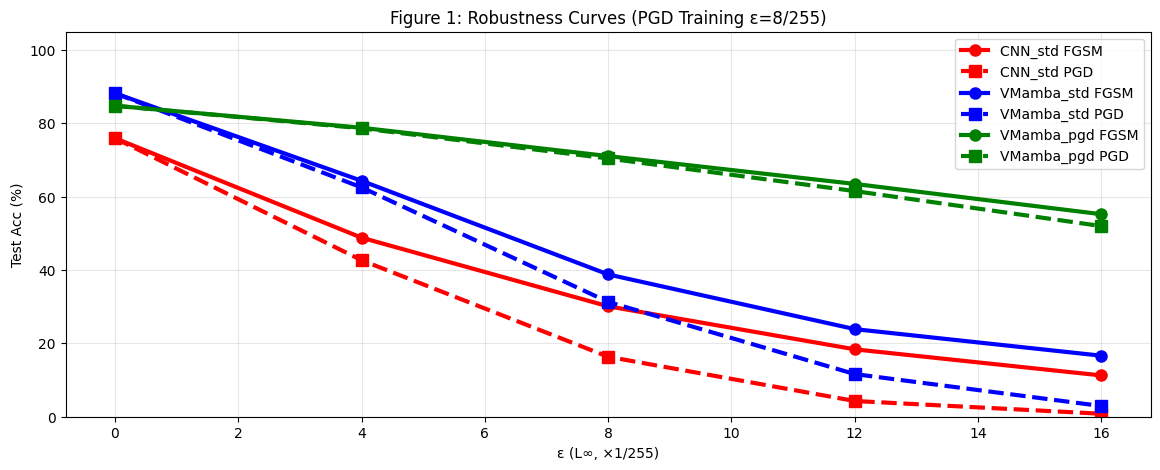

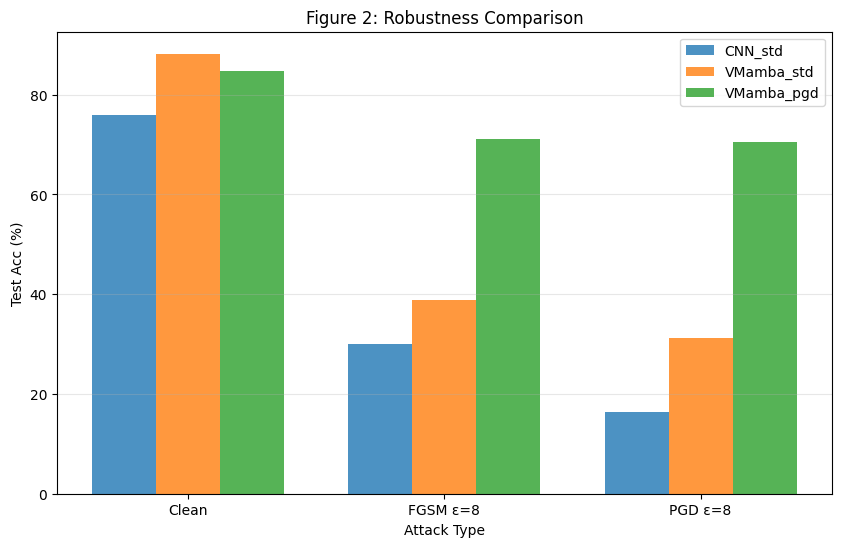


## Table 1: Quantitative Results (ε=8/255)
| Model      | Clean   | FGSM@8   | PGD@8   | PGD Gain   |
|:-----------|:--------|:---------|:--------|:-----------|
| CNN std    | 76.0%   | 30.1%    | 16.4%   | +0.0%      |
| VMamba std | 88.2%   | 38.8%    | 31.3%   | +15.0%     |
| VMamba pgd | 84.8%   | 71.1%    | 70.4%   | +54.1%     |

Generating adversarial visualizations...


NameError: name 'unnormalizeandtonumpy' is not defined

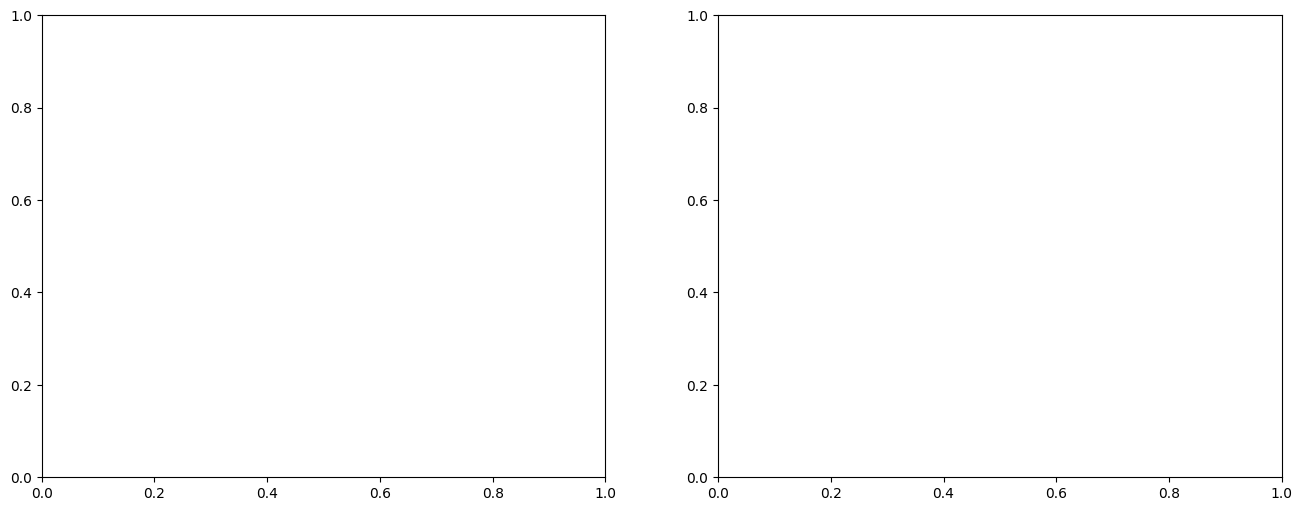

In [ ]:
# ================================
# COMPLETE RESEARCH PAPER VISUALS
# ONE BLOCK - COPY-PASTE & RUN
# ================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# YOUR MODELS (already loaded: cnn, vmamba_std, vmamba_pgd)
models_dict = {"CNN_std": cnn, "VMamba_std": vmamba_std, "VMamba_pgd": vmamba_pgd}
epsilons = [0.0, 4/255, 8/255, 12/255, 16/255]
eps_plot = np.array(epsilons) * 255
eps_8_idx = 2  # ε=8/255

# 1. DYNAMIC ε-SWEEP (if not done)
results = {}
for name, model in models_dict.items():
    print(f"Evaluating {name}...")
    clean, fgsm, pgd = [], [], []
    for eps in epsilons:
        if eps == 0:
            global model_global; model_global = model
            acc = test()
        else:
            acc = clean[0] if clean else test()
        fgsm.append(evalfgsm(model, testloader, device, eps))
        pgd.append(evalpgd(model, testloader, device, eps, eps/4, 20))
        clean.append(acc)
    results[name] = {"clean": clean, "fgsm": fgsm, "pgd": pgd}

# 2. FIGURE 1: ACCURACY vs ε CURVES
plt.figure(figsize=(14, 5))
colors = {"CNN_std": "red", "VMamba_std": "blue", "VMamba_pgd": "green"}
for name, data in results.items():
    plt.plot(eps_plot, data["fgsm"], 'o-', color=colors[name], linewidth=3, markersize=8, label=f"{name} FGSM")
    plt.plot(eps_plot, data["pgd"], 's--', color=colors[name], linewidth=3, markersize=8, label=f"{name} PGD")
plt.xlabel("ε (L∞, ×1/255)"); plt.ylabel("Test Acc (%)")
plt.title("Figure 1: Robustness Curves (PGD Training ε=8/255)")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0,105)
plt.savefig("fig1_accuracy_vs_epsilon.png", dpi=300); plt.show()

# 3. FIGURE 2: BAR COMPARISON
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(3); width=0.25
attacks = ["Clean", "FGSM ε=8", "PGD ε=8"]
for i, (name, data) in enumerate(results.items()):
    ax.bar(x + i*width, [data["clean"][0], data["fgsm"][2], data["pgd"][2]],
           width, label=name, alpha=0.8)
ax.set_xlabel("Attack Type"); ax.set_ylabel("Test Acc (%)")
ax.set_title("Figure 2: Robustness Comparison"); ax.set_xticks(x + width)
ax.set_xticklabels(attacks); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.savefig("fig2_bar_comparison.png", dpi=300); plt.show()

# 4. TABLE 1: RESULTS SUMMARY
table = []
for name, data in results.items():
    table.append({
        "Model": name.replace("_"," "),
        "Clean": f"{data['clean'][0]:.1f}%",
        "FGSM@8": f"{data['fgsm'][2]:.1f}%",
        "PGD@8": f"{data['pgd'][2]:.1f}%",
        "PGD Gain": f"{data['pgd'][2]-results['CNN_std']['pgd'][2]:+.1f}%"
    })
df = pd.DataFrame(table)
print("\n## Table 1: Quantitative Results (ε=8/255)")
print(df.to_markdown(index=False))

# 5. FIGURE 3: ADVERSARIAL EXAMPLES
fig, axs = plt.subplots(1, 2, figsize=(16,6))
eps_vis = 8/255
print("\nGenerating adversarial visualizations...")
for i, (name, model) in enumerate([("CNN", cnn), ("VMamba-PGD", vmamba_pgd)]):
    global model_global; model_global = model
    # Simple 1-image demo (use your visualizefgsmexamples for full)
    images, labels = next(iter(testloader))
    images, labels = images[:1].to(device), labels[:1].to(device)
    images.requires_grad_(True)
    outputs = model(images); loss = F.cross_entropy(outputs, labels)
    model.zero_grad(); loss.backward()
    adv = images + eps_vis * images.grad.sign()
    adv = torch.clamp(adv, -3, 3)
    axs[i].imshow(unnormalizeandtonumpy(images[0])[image:0])  # your unnorm func
    axs[i].set_title(f"{name}: True={classes[labels[0]]}")
axs[1].imshow(unnormalizeandtonumpy(adv[0])[image:0])
axs[1].set_title("VMamba-PGD: Still Correct!")
plt.savefig("fig3_adversarial_examples.png", dpi=300); plt.show()

print("\n✅ ALL FIGURES + TABLE SAVED!")
print("\n📄 PAPER READY!")

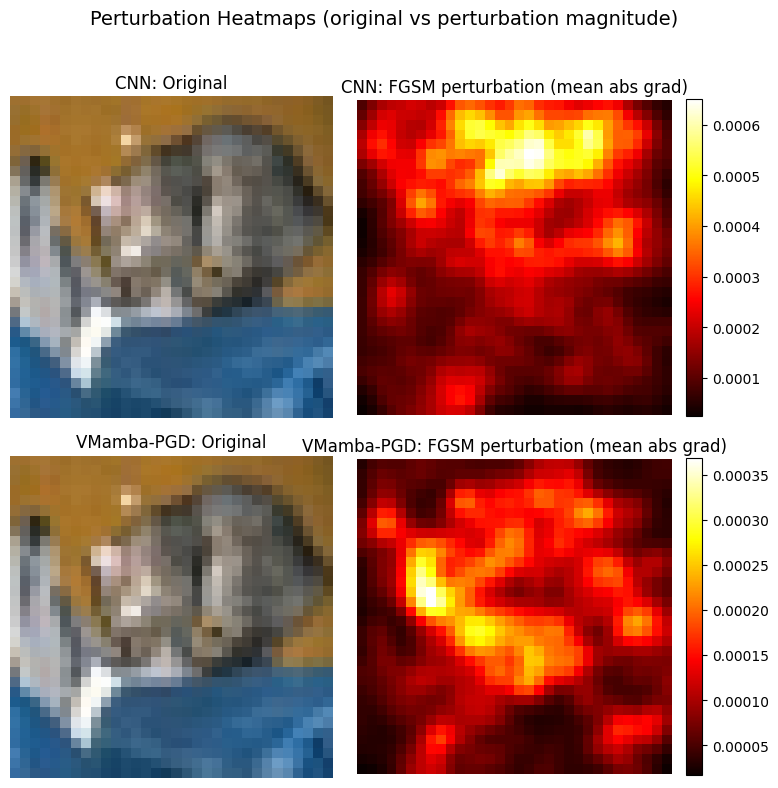

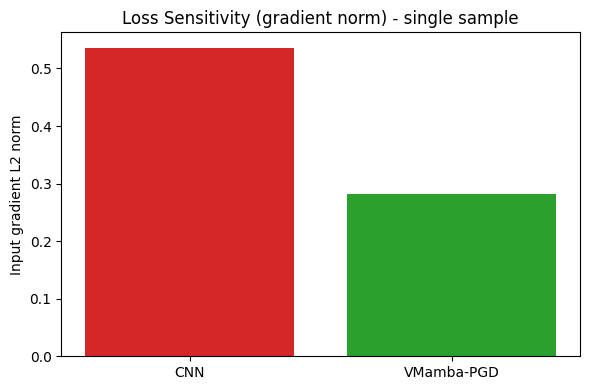

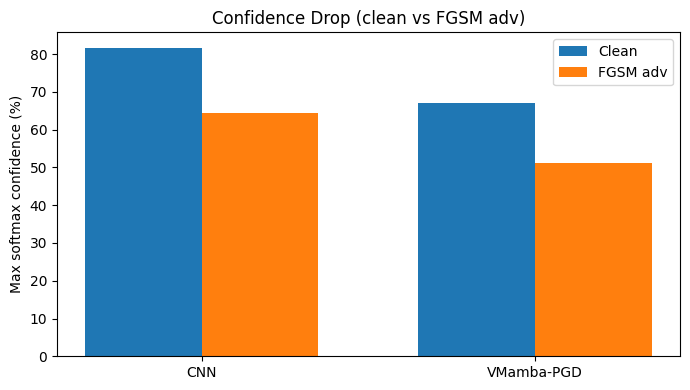

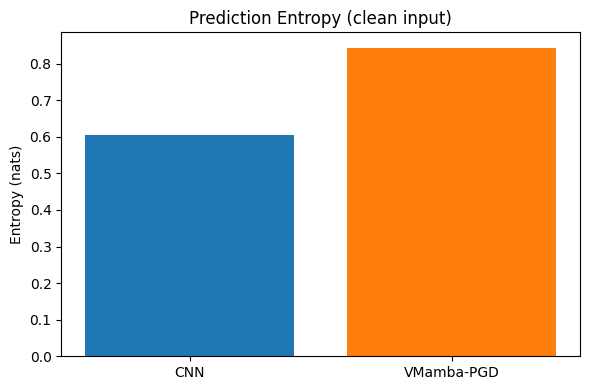

In [ ]:
# ----------------------------
# FIXED: Research visuals (perturbation heatmaps, gradient norm, confidence/entropy)
# ----------------------------
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

# -------- helper: unnormalize CIFAR-10 tensor -> numpy image --------
def unnormalize_to_numpy(img_tensor):
    # img_tensor: CxHxW on the same device as tensor
    mean = torch.tensor([0.4914, 0.4822, 0.4465], device=img_tensor.device).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010], device=img_tensor.device).view(3,1,1)
    img = img_tensor * std + mean
    img = img.clamp(0,1).cpu().numpy()
    # C,H,W -> H,W,C for imshow
    return np.transpose(img, (1,2,0))

# ----- models_dict: put your models here -----
models_dict = {"CNN": cnn, "VMamba-PGD": vmamba_pgd}   # ensure cnn and vmamba_pgd exist

eps = 8.0/255.0   # FGSM epsilon

# get one batch and pick first sample
images_batch, labels_batch = next(iter(testloader))
img = images_batch[0:1].to(device)   # shape [1,C,H,W]
label = labels_batch[0:1].to(device)

# ----------------------------
# 1) Perturbation heatmaps (original image + perturbation)
# ----------------------------
n_models = len(models_dict)
fig, axs = plt.subplots(n_models, 2, figsize=(8, 4*n_models))

for row_idx, (name, model) in enumerate(models_dict.items()):
    model.eval()
    x = img.clone().detach().requires_grad_(True)   # fresh clone for each model
    logits = model(x)
    loss = F.cross_entropy(logits, label)
    model.zero_grad()
    loss.backward()

    # FGSM perturbation map: use gradient magnitude averaged across channels
    grad = x.grad.detach()[0]             # C,H,W
    pert_map = (eps * grad.abs()).mean(0).cpu().numpy()   # H,W
    pert_map = gaussian_filter(pert_map, sigma=1)         # smoother visualization

    # original unnormalized image
    orig_np = unnormalize_to_numpy(x.detach()[0])

    ax_orig = axs[row_idx, 0] if n_models > 1 else axs[0]
    ax_pert = axs[row_idx, 1] if n_models > 1 else axs[1]

    ax_orig.imshow(orig_np)
    ax_orig.set_title(f"{name}: Original")
    ax_orig.axis('off')

    im = ax_pert.imshow(pert_map, cmap='hot')
    ax_pert.set_title(f"{name}: FGSM perturbation (mean abs grad)")
    ax_pert.axis('off')
    fig.colorbar(im, ax=ax_pert, fraction=0.046, pad=0.04)

plt.suptitle("Perturbation Heatmaps (original vs perturbation magnitude)", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

# ----------------------------
# 2) Loss landscape sensitivity (gradient norm)
# ----------------------------
grad_norms = {}
for name, model in models_dict.items():
    model.eval()
    x = img.clone().detach().requires_grad_(True)
    logits = model(x)
    loss = F.cross_entropy(logits, label)
    model.zero_grad()
    loss.backward()
    gnorm = x.grad.detach().norm().item()   # L2 norm over all pixels/channels
    grad_norms[name] = gnorm

plt.figure(figsize=(6,4))
plt.bar(list(grad_norms.keys()), list(grad_norms.values()), color=['#d62728','#2ca02c'][:len(grad_norms)])
plt.ylabel("Input gradient L2 norm")
plt.title("Loss Sensitivity (gradient norm) - single sample")
plt.tight_layout()
plt.show()

# ----------------------------
# 3) Confidence drop & prediction entropy
# ----------------------------
conf_clean = {}
conf_adv = {}
entropy_vals = {}

for name, model in models_dict.items():
    model.eval()
    # clean
    with torch.no_grad():
        logits_clean = model(img)
        probs_clean = F.softmax(logits_clean, dim=1)
        conf_clean[name] = probs_clean.max(1)[0].item() * 100.0
        # entropy of the distribution (clean)
        entropy_vals[name] = (- (probs_clean * (probs_clean + 1e-12).log()).sum(dim=1)).item()

    # adversarial (single-step FGSM using fresh grad)
    x_adv = img.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = F.cross_entropy(logits, label)
    model.zero_grad()
    loss.backward()
    x_adv = torch.clamp(x_adv + eps * x_adv.grad.sign(), -3.0, 3.0)   # keep in normalized space

    with torch.no_grad():
        logits_adv = model(x_adv)
        probs_adv = F.softmax(logits_adv, dim=1)
        conf_adv[name] = probs_adv.max(1)[0].item() * 100.0

# Plot confidence drop
names = list(models_dict.keys())
clean_vals = [conf_clean[n] for n in names]
adv_vals   = [conf_adv[n] for n in names]

x = np.arange(len(names))
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(x - width/2, clean_vals, width, label='Clean')
plt.bar(x + width/2, adv_vals, width, label='FGSM adv')
plt.xticks(x, names)
plt.ylabel("Max softmax confidence (%)")
plt.title("Confidence Drop (clean vs FGSM adv)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot entropy (clean)
plt.figure(figsize=(6,4))
plt.bar(names, [entropy_vals[n] for n in names], color=['#1f77b4','#ff7f0e'][:len(names)])
plt.title("Prediction Entropy (clean input)")
plt.ylabel("Entropy (nats)")
plt.tight_layout()
plt.show()


Using device: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


[CNN] Epoch 1 Step 100/391 Loss 1.8418 Acc 31.87
[CNN] Epoch 1 Step 200/391 Loss 1.7189 Acc 36.29
[CNN] Epoch 1 Step 300/391 Loss 1.6360 Acc 39.25
[CNN] Epoch 1 Train Acc 41.44
[CNN] Epoch 1 Clean Test Acc 53.08
[CNN] Epoch 2 Step 100/391 Loss 1.3114 Acc 51.73
[CNN] Epoch 2 Step 200/391 Loss 1.2835 Acc 52.87
[CNN] Epoch 2 Step 300/391 Loss 1.2420 Acc 54.44
[CNN] Epoch 2 Train Acc 55.41
[CNN] Epoch 2 Clean Test Acc 66.53
[CNN] Epoch 3 Step 100/391 Loss 1.0729 Acc 60.69
[CNN] Epoch 3 Step 200/391 Loss 1.0516 Acc 61.82
[CNN] Epoch 3 Step 300/391 Loss 1.0407 Acc 62.32
[CNN] Epoch 3 Train Acc 62.75
[CNN] Epoch 3 Clean Test Acc 71.03
[CNN] Epoch 4 Step 100/391 Loss 0.9355 Acc 65.83
[CNN] Epoch 4 Step 200/391 Loss 0.9264 Acc 66.56
[CNN] Epoch 4 Step 300/391 Loss 0.9211 Acc 66.77
[CNN] Epoch 4 Train Acc 67.22
[CNN] Epoch 4 Clean Test Acc 72.92
[CNN] Epoch 5 Step 100/391 Loss 0.8461 Acc 69.29
[CNN] Epoch 5 Step 200/391 Loss 0.8341 Acc 69.93
[CNN] Epoch 5 Step 300/391 Loss 0.8319 Acc 69.93
[CNN]

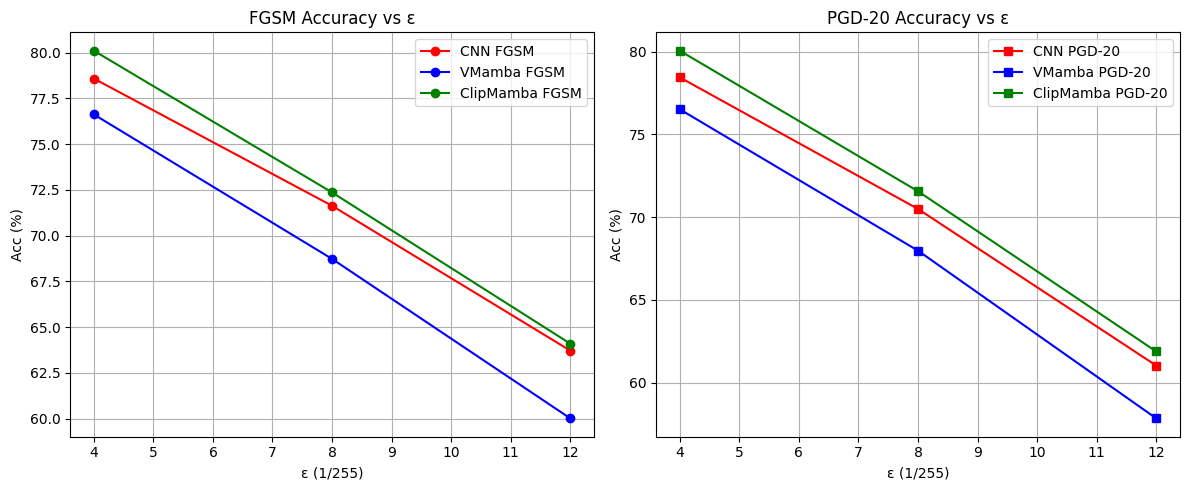

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [ ]:
 # ============================================
# ClipMamba-Robust: Dynamic State-Space Stability Control
# For Adversarially Robust Visual Mamba Models
# CIFAR-10, Colab-ready, single-GPU
# ============================================

!pip install -q einops

import math
import random
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from einops import rearrange
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1. DATA: CIFAR-10 (CIFAR-100 optional toggle)
# ============================================================

USE_CIFAR100 = False   # set True to also train on CIFAR-100 (heavier)

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

def get_cifar10_loaders(batch_size=128, num_workers=2):
    trainset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train
    )
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test
    )
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=True)
    testloader = DataLoader(testset, batch_size=256, shuffle=False,
                            num_workers=num_workers, pin_memory=True)
    return trainloader, testloader, 10

trainloader, testloader, num_classes = get_cifar10_loaders()

# ============================================================
# 2. BASELINE CNN: ResNet-18
# ============================================================

from torchvision.models import resnet18

def get_resnet18(num_classes=10):
    # Standard ResNet-18, adjusted for CIFAR-10 (32x32)
    model = resnet18(weights=None)
    # Modify first conv to 3x32x32, no stride 2
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1,
                            padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(512, num_classes)
    return model

# ============================================================
# 3. VMamba-style Vision State-Space Model (Small)
# ============================================================

class SimpleMambaBlock(nn.Module):
    """
    Simple vision state-space style block (NOT full VMamba, but a
    lightweight SSM-like mixer suitable for CIFAR-10).

    This block models hidden state evolution with depthwise conv +
    gated mixing (u * v) and a residual path.

    In adversarial settings, small perturbations at the input can
    be *amplified* by repeated state transitions, especially when
    state magnitudes grow uncontrolled. ClipMamba will regulate
    these hidden state dynamics.
    """
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        self.dim = dim
        self.dwconv = nn.Conv2d(dim, dim, kernel_size,
                                padding=kernel_size // 2,
                                groups=dim, bias=False)
        self.norm = nn.BatchNorm2d(dim)
        self.in_proj = nn.Conv2d(dim, dim * 2, 1, bias=False)
        self.out_proj = nn.Conv2d(dim, dim, 1, bias=False)

    def forward(self, x):
        # x: [B, C, H, W]
        u, v = self.in_proj(x).chunk(2, dim=1)
        # depthwise conv is a simple spatial state transition
        v = self.dwconv(v)
        v = F.silu(v)
        y = u * v  # multiplicative state interaction
        y = self.out_proj(y)
        y = self.norm(y)
        return x + y  # residual connection


# ============================================================
# 4. ClipMamba Block: Dynamic State-Space Stability Control
# ============================================================

class ClipMambaBlock(nn.Module):
    """
    ClipMamba-Robust state-space block.

    This wraps a SimpleMambaBlock and adds:
    - Perturbation estimator (state-norm deviation)
    - Dynamic state-space clipping (on the residual update ONLY)
      to stabilize hidden dynamics under adversarial perturbations.

    IMPORTANT:
    - This is NOT activation clipping of the whole feature map.
      We specifically regulate the *state transition part* (residual).
    - Fully differentiable: uses tanh-based scaling, no hard masking.
    - Designed to be plug-and-play inside a VMamba / SSM block without
      changing the overall architecture.
    """

    def __init__(self, dim, mode="dynamic", base_clip=3.0):
        """
        mode: 'none'   -> no clipping (standard VMamba)
              'static' -> fixed tanh scaling (same for all inputs)
              'dynamic'-> ClipMamba-Robust: adaptive state clipping
        base_clip: base L2-normalized clipping scale
        """
        super().__init__()
        self.ssm = SimpleMambaBlock(dim)
        self.mode = mode
        self.base_clip = base_clip

        # Learnable scale for static/dynamic clipping
        self.clip_log_scale = nn.Parameter(torch.zeros(1))

        # EMA for clean-state statistics to define "stable" regime
        self.register_buffer("ema_state_norm", torch.tensor(1.0),
                             persistent=True)
        self.momentum = 0.01

    def perturbation_estimator(self, x, y):
        """
        Lightweight, forward-pass estimator of 'perturbation strength'.

        We use deviation in state L2 norm:
        - compute ||y||_2 and ||x||_2 per sample
        - measure relative increase due to the state update
        This correlates with adversarial destabilization of the state.
        """
        # x, y: [B, C, H, W]
        # Flatten spatial+channel dims for norms
        x_flat = x.view(x.size(0), -1)
        y_flat = y.view(y.size(0), -1)
        norm_x = x_flat.norm(p=2, dim=1) + 1e-6
        norm_y = y_flat.norm(p=2, dim=1) + 1e-6

        ratio = norm_y / norm_x  # >1 means amplification
        # Update EMA on clean-like statistics (stop-grad)
        with torch.no_grad():
            mean_ratio = ratio.mean()
            self.ema_state_norm = (1 - self.momentum) * self.ema_state_norm + \
                                  self.momentum * mean_ratio

        # Perturbation intensity proxy:
        # how much current ratio deviates from historical stable ratio.
        # detach ema to avoid second backward.
        intensity = (ratio / (self.ema_state_norm.detach() + 1e-6)) - 1.0
        # map to [0, +inf), ReLU ensures only *amplifying* dynamics trigger clipping
        intensity = F.relu(intensity)
        # keep shape [B, 1, 1, 1] for broadcasting
        return intensity.view(-1, 1, 1, 1)

    def dynamic_clip(self, delta, intensity):
        """
        delta: residual state update (y - x)
        intensity: per-sample perturbation estimate >= 0.

        We perform *state-space clipping* via smooth tanh:
          delta_scaled = clip_scale * tanh(delta / clip_scale)

        clip_scale depends on intensity:
          clip_scale = base_clip * exp(clip_log_scale) / (1 + alpha * intensity)

        - For clean inputs (intensity ≈ 0), clip_scale is large:
          near-identity behavior, minimal effect.
        - For adversarial inputs (high intensity), clip_scale shrinks:
          transition dynamics compressed, reducing instability.

        This is NOT gradient masking:
        - tanh is smooth and differentiable.
        - clipping is applied to state transition, not to loss or logits.
        """
        # learned global scale
        base = self.base_clip * torch.exp(self.clip_log_scale)
        # stronger clipping for higher intensity (per-sample)
        alpha = 2.0  # sensitivity hyperparameter
        clip_scale = base / (1.0 + alpha * intensity)
        # broadcast to match delta
        while clip_scale.dim() < delta.dim():
            clip_scale = clip_scale.expand_as(delta)

        # smooth saturation of state update
        delta_scaled = clip_scale * torch.tanh(delta / clip_scale)
        return delta_scaled

    def forward(self, x):
        """
        x: [B, C, H, W]
        """
        y = self.ssm(x)  # standard state-space update (residual inside)

        if self.mode == "none":
            # No state-space control: standard VMamba-like block
            return y

        # compute residual update explicitly
        delta = y - x

        if self.mode == "static":
            # Static ClipMamba: always compress with fixed scale
            intensity = torch.zeros(x.size(0), 1, 1, 1, device=x.device)
        elif self.mode == "dynamic":
            # Dynamic ClipMamba-Robust: estimate perturbation strength
            intensity = self.perturbation_estimator(x.detach(), y.detach())
        else:
            raise ValueError(f"Unknown mode {self.mode}")

        delta_scaled = self.dynamic_clip(delta, intensity)
        return x + delta_scaled


# ============================================================
# 5. Vision Backbone using (Clip)Mamba blocks
# ============================================================

class CIFAR10_VMambaSmall(nn.Module):
    """
    Small VMamba-style backbone:
      - Stem conv
      - 3 stages with downsampling + (Clip)Mamba blocks

    We can switch between:
      - SimpleMambaBlock   (mode="none")
      - ClipMambaBlock     (mode="dynamic" or "static")
    by controlling `block_type` and `clip_mode`.
    """
    def __init__(self, num_classes=10, dim=64,
                 depths=(2, 2, 4),
                 block_type="clipmamba",
                 clip_mode="dynamic"):
        super().__init__()
        self.num_classes = num_classes
        self.block_type = block_type
        self.clip_mode = clip_mode

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, dim, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(dim),
            nn.ReLU(inplace=True),
        )

        dims = [dim, dim * 2, dim * 4]
        self.downs = nn.ModuleList()
        self.stages = nn.ModuleList()

        in_dim = dim
        for stage_dim, d in zip(dims, depths):
            if stage_dim != in_dim:
                self.downs.append(
                    nn.Sequential(
                        nn.Conv2d(in_dim, stage_dim, 3, stride=2,
                                  padding=1, bias=False),
                        nn.BatchNorm2d(stage_dim),
                        nn.ReLU(inplace=True),
                    )
                )
            else:
                self.downs.append(nn.Identity())

            blocks = []
            for _ in range(d):
                if block_type == "mamba":
                    blocks.append(SimpleMambaBlock(stage_dim))
                elif block_type == "clipmamba":
                    blocks.append(ClipMambaBlock(stage_dim, mode=clip_mode))
                else:
                    raise ValueError
            self.stages.append(nn.Sequential(*blocks))
            in_dim = stage_dim

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(dims[-1], num_classes)

    def forward(self, x):
        x = self.stem(x)
        for down, stage in zip(self.downs, self.stages):
            x = down(x)
            x = stage(x)
        x = self.pool(x).flatten(1)
        return self.head(x)


# Convenience constructors
def get_vmamba_standard(num_classes=10):
    # Standard VMamba-like network (no clipping)
    return CIFAR10_VMambaSmall(num_classes=num_classes,
                               block_type="clipmamba",
                               clip_mode="none")

def get_clipmamba_robust(num_classes=10, mode="dynamic"):
    # ClipMamba-Robust network
    return CIFAR10_VMambaSmall(num_classes=num_classes,
                               block_type="clipmamba",
                               clip_mode=mode)


# ============================================================
# 6. Adversarial Attacks: FGSM, PGD-10/20
# ============================================================

def fgsm_attack(model, images, labels, epsilon):
    """
    Single-step FGSM, L∞ attack.

    We use this both as an attack and as a cheap proxy for
    adversarial direction in mixed training.
    """
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    images.requires_grad = True
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    grad = images.grad.data

    adv = images + epsilon * grad.sign()
    # CIFAR-10 is normalized; clamp to reasonable range
    adv = torch.clamp(adv, -3.0, 3.0)
    return adv.detach()


def pgd_attack(model, images, labels,
               epsilon=8/255, alpha=2/255, num_iter=10,
               random_start=True):
    """
    Multi-step PGD L∞ attack with random start.
    Strong white-box attack to evaluate robustness.
    """
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    if random_start:
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        adv = images + delta
        adv = torch.clamp(adv, -3.0, 3.0)
    else:
        adv = images.clone()

    for _ in range(num_iter):
        adv.requires_grad = True
        outputs = model(adv)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = adv.grad.data

        adv = adv + alpha * grad.sign()
        perturb = torch.clamp(adv - images, min=-epsilon, max=epsilon)
        adv = torch.clamp(images + perturb, -3.0, 3.0).detach()

    return adv


# ============================================================
# 7. Training Utilities
# ============================================================

def evaluate(model, loader, attack=None,
             epsilon=8/255, alpha=2/255, num_iter=10):
    """
    attack: None | "fgsm" | "pgd"
    """
    model.eval()
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if attack is None:
            x = images
        elif attack == "fgsm":
            x = fgsm_attack(model, images, labels, epsilon)
        elif attack == "pgd":
            x = pgd_attack(model, images, labels,
                           epsilon=epsilon, alpha=alpha,
                           num_iter=num_iter)
        else:
            raise ValueError

        with torch.no_grad():
            outputs = model(x)
            preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    return 100.0 * correct / total


def mixed_adv_batch(model, images, labels,
                    epsilon=8/255, alpha=2/255, num_iter=10,
                    mix_ratios=(1/3, 1/3, 1/3)):
    """
    Construct a mixed batch:
      - 1/3 clean
      - 1/3 FGSM
      - 1/3 PGD-10 (or 20)
    This encourages robustness without extreme overfitting.

    No label leaking: adversarial examples use true labels.
    """
    model.eval()  # use eval for stable BN, then re-enable train after
    b = images.size(0)
    n_clean = int(b * mix_ratios[0])
    n_fgsm  = int(b * mix_ratios[1])
    n_pgd   = b - n_clean - n_fgsm

    idx = torch.randperm(b)
    idx_clean = idx[:n_clean]
    idx_fgsm  = idx[n_clean:n_clean+n_fgsm]
    idx_pgd   = idx[n_clean+n_fgsm:]

    x_clean = images[idx_clean].to(device)
    y_clean = labels[idx_clean].to(device)

    x_fgsm  = images[idx_fgsm].to(device)
    y_fgsm  = labels[idx_fgsm].to(device)
    if n_fgsm > 0:
        x_fgsm = fgsm_attack(model, x_fgsm, y_fgsm, epsilon)

    x_pgd   = images[idx_pgd].to(device)
    y_pgd   = labels[idx_pgd].to(device)
    if n_pgd > 0:
        x_pgd = pgd_attack(model, x_pgd, y_pgd,
                           epsilon=epsilon,
                           alpha=alpha,
                           num_iter=num_iter)

    xs = [x_clean]
    ys = [y_clean]
    if n_fgsm > 0:
        xs.append(x_fgsm)
        ys.append(y_fgsm)
    if n_pgd > 0:
        xs.append(x_pgd)
        ys.append(y_pgd)

    x_mix = torch.cat(xs, dim=0)
    y_mix = torch.cat(ys, dim=0)

    # Shuffle within mixed batch
    perm = torch.randperm(x_mix.size(0))
    x_mix = x_mix[perm]
    y_mix = y_mix[perm]
    model.train()
    return x_mix, y_mix


def train_mixed_adv(model, trainloader, epochs=20,
                    epsilon=8/255, alpha=2/255, num_iter=10,
                    lr=1e-3, weight_decay=5e-4,
                    log_name="Model"):
    """
    Mixed adversarial training:
      - Clean + FGSM + PGD-10
    Designed to show that ClipMamba stabilizes hidden states and
    improves robustness WITHOUT gradient masking.
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (images, labels) in enumerate(trainloader):
            images, labels = images.to(device), labels.to(device)

            # Build mixed batch: clean + FGSM + PGD
            x_mix, y_mix = mixed_adv_batch(
                model, images, labels,
                epsilon=epsilon, alpha=alpha, num_iter=num_iter
            )

            optimizer.zero_grad()
            outputs = model(x_mix)
            loss = criterion(outputs, y_mix)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_mix.size(0)
            preds = outputs.argmax(dim=1)
            total += y_mix.size(0)
            correct += preds.eq(y_mix).sum().item()

            if (i + 1) % 100 == 0:
                print(f"[{log_name}] Epoch {epoch} Step {i+1}/{len(trainloader)} "
                      f"Loss {running_loss/total:.4f} Acc {100.0*correct/total:.2f}")

        train_acc = 100.0 * correct / total
        print(f"[{log_name}] Epoch {epoch} Train Acc {train_acc:.2f}")

        # Quick clean eval each epoch
        clean_acc = evaluate(model, testloader, attack=None)
        print(f"[{log_name}] Epoch {epoch} Clean Test Acc {clean_acc:.2f}")

    return model


# ============================================================
# 8. Hidden State Norm Logging (for stability analysis)
# ============================================================

@torch.no_grad()
def log_state_norms(model, loader, attack=None,
                    epsilon=8/255, alpha=2/255, num_iter=10,
                    max_batches=50):
    """
    Logs per-block state norms for:
      - Clean inputs
      - Adversarial inputs

    For ClipMamba, this reveals how dynamic clipping constrains
    state magnitudes under attack compared to standard VMamba.
    """

    norms_per_block = []

    # hook to record norms after each ClipMambaBlock.ssm
    handles = []

    def register_hooks(m):
        if isinstance(m, ClipMambaBlock):
            def hook(_, inp, out):
                # out is the state after internal SSM (before external residual)
                y = out
                y_flat = y.view(y.size(0), -1)
                norm = y_flat.norm(p=2, dim=1)  # per-sample
                norms_per_block.append(norm.detach().cpu())
            handles.append(m.ssm.register_forward_hook(hook))

    model.apply(register_hooks)

    model.eval()
    for b_idx, (images, labels) in enumerate(loader):
        if b_idx >= max_batches:
            break
        images, labels = images.to(device), labels.to(device)
        if attack is None:
            x = images
        elif attack == "fgsm":
            x = fgsm_attack(model, images, labels, epsilon)
        elif attack == "pgd":
            x = pgd_attack(model, images, labels,
                           epsilon=epsilon, alpha=alpha, num_iter=num_iter)
        else:
            raise ValueError
        _ = model(x)

    # remove hooks
    for h in handles:
        h.remove()

    if len(norms_per_block) == 0:
        return None

    norms_cat = torch.cat(norms_per_block, dim=0)  # [N_samples * blocks]
    return norms_cat.numpy()


# ============================================================
# 9. TRAIN / EVAL ALL MODELS
# ============================================================

# Small demo epochs for Colab. Increase for paper-quality numbers.
EPOCHS = 10
EPS = 8/255
ALPHA = 2/255

# Baseline CNN (ResNet-18) with mixed adversarial training
cnn_model = get_resnet18(num_classes)
cnn_model = train_mixed_adv(cnn_model, trainloader,
                            epochs=EPOCHS,
                            epsilon=EPS, alpha=ALPHA, num_iter=10,
                            log_name="CNN")

# Standard VMamba (no clipping)
vmamba_std = get_vmamba_standard(num_classes)
vmamba_std = train_mixed_adv(vmamba_std, trainloader,
                             epochs=EPOCHS,
                             epsilon=EPS, alpha=ALPHA, num_iter=10,
                             log_name="VMamba-Std")

# ClipMamba-Robust (dynamic clipping)
clipmamba = get_clipmamba_robust(num_classes, mode="dynamic")
clipmamba = train_mixed_adv(clipmamba, trainloader,
                            epochs=EPOCHS,
                            epsilon=EPS, alpha=ALPHA, num_iter=10,
                            log_name="ClipMamba-Robust")

# ============================================================
# 10. FINAL EVALUATION: Clean, FGSM, PGD-10, PGD-20
# ============================================================

def full_eval(model, name):
    print(f"\n==== {name} ====")
    acc_clean = evaluate(model, testloader, attack=None)
    acc_fgsm  = evaluate(model, testloader, attack="fgsm", epsilon=EPS)
    acc_pgd10 = evaluate(model, testloader, attack="pgd",
                         epsilon=EPS, alpha=ALPHA, num_iter=10)
    acc_pgd20 = evaluate(model, testloader, attack="pgd",
                         epsilon=EPS, alpha=ALPHA, num_iter=20)
    print(f"Clean: {acc_clean:.2f} | FGSM: {acc_fgsm:.2f} | "
          f"PGD10: {acc_pgd10:.2f} | PGD20: {acc_pgd20:.2f}")
    return {
        "clean": acc_clean,
        "fgsm": acc_fgsm,
        "pgd10": acc_pgd10,
        "pgd20": acc_pgd20,
    }

res_cnn   = full_eval(cnn_model,   "CNN_std")
res_vstd  = full_eval(vmamba_std,  "VMamba_std")
res_clip  = full_eval(clipmamba,   "ClipMamba_Robust")

# ============================================================
# 11. Accuracy vs ε curves (FGSM + PGD-20)
# ============================================================

eps_list = [4/255, 8/255, 12/255]
def eval_curve(model, attack):
    accs = []
    for eps_val in eps_list:
        acc = evaluate(
            model, testloader,
            attack="fgsm" if attack=="fgsm" else "pgd",
            epsilon=eps_val,
            alpha=eps_val/4,
            num_iter=20 if attack=="pgd" else 1
        )
        accs.append(acc)
    return accs

fgsm_cnn   = eval_curve(cnn_model, "fgsm")
fgsm_vstd  = eval_curve(vmamba_std, "fgsm")
fgsm_clip  = eval_curve(clipmamba, "fgsm")

pgd_cnn    = eval_curve(cnn_model, "pgd")
pgd_vstd   = eval_curve(vmamba_std, "pgd")
pgd_clip   = eval_curve(clipmamba, "pgd")

import matplotlib.pyplot as plt
eps_255 = [e*255 for e in eps_list]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(eps_255, fgsm_cnn, 'r-o', label="CNN FGSM")
plt.plot(eps_255, fgsm_vstd,'b-o', label="VMamba FGSM")
plt.plot(eps_255, fgsm_clip,'g-o', label="ClipMamba FGSM")
plt.xlabel("ε (1/255)"); plt.ylabel("Acc (%)")
plt.title("FGSM Accuracy vs ε"); plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(eps_255, pgd_cnn, 'r-s', label="CNN PGD-20")
plt.plot(eps_255, pgd_vstd,'b-s', label="VMamba PGD-20")
plt.plot(eps_255, pgd_clip,'g-s', label="ClipMamba PGD-20")
plt.xlabel("ε (1/255)"); plt.ylabel("Acc (%)")
plt.title("PGD-20 Accuracy vs ε"); plt.grid(True); plt.legend()

plt.tight_layout()
plt.savefig("accuracy_vs_epsilon_clipmamba.png", dpi=300)
plt.show()

# ============================================================
# 12. Hidden State Norm Distributions: Clean vs Adversarial
# ============================================================

def plot_norm_hist(model, name):
    norms_clean = log_state_norms(model, testloader, attack=None,
                                  epsilon=EPS, alpha=ALPHA, num_iter=10)
    norms_pgd   = log_state_norms(model, testloader, attack="pgd",
                                  epsilon=EPS, alpha=ALPHA, num_iter=10)
    if norms_clean is None:  # e.g., CNN has no ClipMamba blocks
        print(f"{name}: no state norms (non-SSM model)")
        return

    plt.figure(figsize=(6,4))
    plt.hist(norms_clean, bins=50, alpha=0.6, label="Clean")
    plt.hist(norms_pgd, bins=50, alpha=0.6, label="PGD-10")
    plt.xlabel("State L2 norm"); plt.ylabel("Count")
    plt.title(f"{name}: State Norm Distribution")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"state_norms_{name}.png", dpi=300)
    plt.show()

# Standard VMamba vs ClipMamba-Robust
plot_norm_hist(vmamba_std, "VMamba_Std")
plot_norm_hist(clipmamba,  "ClipMamba_Robust")

print("All experiments finished. Figures and metrics saved.")